# CML7133 Assignment 2
## Predicting the direction of an Indian stock using technical indicators

**Name:** Umer Majid Muneer &nbsp;&nbsp; **Student ID:** 261PC260Y3 &nbsp;&nbsp;
**Subject:** CML7133
**Lecturer:** _(fill in)_ &nbsp;&nbsp; **Group members:** _(fill in)_

---
**Stock:** Infosys (INFY.NS), NSE India. Daily data 1996&ndash;2026, about 7,700 trading days,
from Yahoo Finance via `yfinance`.

**Question:** from today's chart, can I predict whether the price will be higher or lower
in *n* days?

**Three model types on the same features, as the assignment requires:** classification
(up or down), regression (the actual return), clustering (what kinds of market conditions
exist).

**Why Infosys:** I checked several Indian stocks first. Reliance and TCS each had single
days that appear to move over 200%, which are corporate actions rather than real price
moves. Infosys has no move above 30% in 30 years and has real volume on 98% of days.

**What I expect:** not high accuracy. If I got 90% I would assume a bug. A few percent
over a sensible baseline, properly validated, is the realistic target.

In [1]:
import warnings, os, time, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "notebook_connected"
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 96, "font.size": 8})
pd.set_option("display.width", 110)

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import (TimeSeriesSplit, cross_val_score, KFold,
                                     RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   KBinsDiscretizer)
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, IsolationForest,
                              VotingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.feature_selection import mutual_info_classif, f_classif, RFECV
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             average_precision_score, matthews_corrcoef,
                             cohen_kappa_score, confusion_matrix, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
import xgboost as xgb, lightgbm as lgb, shap
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import spearmanr, wilcoxon, kruskal, ttest_ind, mannwhitneyu
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.contingency_tables import mcnemar

TICKER, STOCK = "INFY.NS", "Infosys"
HORIZONS, LAGS = [1, 2, 3, 5, 10, 21], [1, 2, 3, 5, 10]
N_SPLITS, N_SPLITS_STATS, N_TREES, TUNE_N = 5, 10, 250, 6
print("Libraries loaded.")

Libraries loaded.


## 1. Data
`yfinance` first, with a saved CSV as a fallback so the notebook runs offline.
**Split adjustment:** Yahoo adjusts `Close` for splits but not Open/High/Low. On a split
day the raw close halves, which a model would read as a crash. I apply the same ratio to
all four price columns so they stay consistent.

In [2]:
def get_data():
    try:
        import yfinance as yf
        raw = yf.download(TICKER, start="1996-01-01", end="2026-09-29",
                          progress=False, auto_adjust=False)
        if raw is None or len(raw) == 0:
            raise ValueError("empty")
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = [c[0] for c in raw.columns]
        raw = raw.reset_index()
        f = raw["Adj Close"] / raw["Close"]
        for c in ["Open", "High", "Low", "Close"]:
            raw[c] = raw[c] * f
        src = "yfinance"
    except Exception as e:
        print(f"yfinance unavailable ({type(e).__name__}); using saved CSV")
        raw = pd.read_csv(next(p for p in ["INFY_NS.csv", "data/INFY_NS.csv",
                                           "../data/INFY_NS.csv"] if os.path.exists(p)))
        src = "csv"
    raw["Date"] = pd.to_datetime(raw["Date"])
    d = raw[["Date", "Open", "High", "Low", "Close", "Volume"]].set_index("Date").sort_index()
    return d[~d.index.duplicated(keep="last")], src

df, SOURCE = get_data()
HAS_VOLUME = (df["Volume"] > 0).mean() > 0.5
print(f"source={SOURCE}  shape={df.shape}  {df.index.min().date()} to {df.index.max().date()}")
print(f"missing values: {df.isna().sum().sum()}   "
      f"High>=Low always: {bool((df['High']>=df['Low']).all())}   "
      f"volume usable: {HAS_VOLUME} ({100*(df['Volume']>0).mean():.1f}% non-zero)")
df.head(3)

Cookie fetch from fc.yahoo.com failed (ConnectionError), continuing without it


Cookie/crumb fetch failed (ConnectionError), continuing without crumb


Failed to get ticker 'INFY.NS' reason: Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Cookie/crumb fetch failed (ConnectionError), continuing without crumb



1 Failed download:


['INFY.NS']: ConnectionError('Failed to perform, curl: (7) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


yfinance unavailable (ValueError); using saved CSV
source=csv  shape=(7720, 5)  1996-01-01 to 2026-09-28
missing values: 0   High>=Low always: True   volume usable: True (98.4% non-zero)


,Open,High,Low,Close,Volume
Date,,,,,
1996-01-01,0.467356,0.468390,0.465060,0.468390,204800
1996-01-02,0.467356,0.469654,0.466496,0.466496,204800
1996-01-03,0.469654,0.469654,0.469654,0.469654,102400


## 2. Feature engineering
**Key decision:** Infosys traded under 1 rupee in 1996 and near 1000 today, so raw price
levels are useless as features &mdash; every test value would sit outside the training
range. Every price-based indicator is therefore expressed as a *relative* quantity
("3% above the 20-day average" rather than "950 rupees").

RSI, KDJ and BBI are written out from their definitions rather than taken from a library,
since the assignment names them specifically.

In [3]:
def smooth(s, n):
    """Wilder's smoothing (EMA with alpha=1/n). Used by RSI, ATR, ADX."""
    return s.ewm(alpha=1/n, adjust=False).mean()

def get_rsi(c, n=14):
    ch = c.diff()
    rs = smooth(ch.clip(lower=0), n) / smooth(-ch.clip(upper=0), n).replace(0, np.nan)
    return (100 - 100/(1+rs)).fillna(50)

def get_stoch(h, l, c, n=9, ks=3, ds=3):
    """Where the close sits inside the recent high-low range."""
    ll, hh = l.rolling(n).min(), h.rolling(n).max()
    raw = 100*(c-ll)/(hh-ll).replace(0, np.nan)
    k = raw.ewm(alpha=1/ks, adjust=False).mean()
    return raw, k, k.ewm(alpha=1/ds, adjust=False).mean()

def get_kdj(h, l, c, n=9):
    """J = 3K - 2D exaggerates the K/D gap, so it may leave 0-100."""
    _, k, d = get_stoch(h, l, c, n)
    return k, d, 3*k - 2*d

def get_bbi(c):
    """Bull and Bear Index: mean of the 3, 6, 12 and 24 period averages."""
    return (c.rolling(3).mean()+c.rolling(6).mean()+c.rolling(12).mean()+c.rolling(24).mean())/4

def get_macd(c, f=12, s=26, sig=9):
    line = c.ewm(span=f, adjust=False).mean() - c.ewm(span=s, adjust=False).mean()
    sg = line.ewm(span=sig, adjust=False).mean()
    return line, sg, line - sg

def get_boll(c, n=20, k=2):
    m, sd = c.rolling(n).mean(), c.rolling(n).std()
    up, lo = m + k*sd, m - k*sd
    return up, lo, m, (up-lo)/m.replace(0, np.nan), (c-lo)/(up-lo).replace(0, np.nan)

def get_atr(h, l, c, n=14):
    tr = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    return smooth(tr, n)

def get_adx(h, l, c, n=14):
    """ADX = trend strength; +DI/-DI give direction."""
    up, dn = h.diff(), -l.diff()
    p = np.where((up > dn) & (up > 0), up, 0.0)
    m = np.where((dn > up) & (dn > 0), dn, 0.0)
    a = get_atr(h, l, c, n)
    pdi = 100*smooth(pd.Series(p, index=h.index), n)/a.replace(0, np.nan)
    mdi = 100*smooth(pd.Series(m, index=h.index), n)/a.replace(0, np.nan)
    dx = 100*(pdi-mdi).abs()/(pdi+mdi).replace(0, np.nan)
    return pdi, mdi, smooth(dx, n)

def get_willr(h, l, c, n=14):
    hh, ll = h.rolling(n).max(), l.rolling(n).min()
    return -100*(hh-c)/(hh-ll).replace(0, np.nan)

def get_cci(h, l, c, n=20):
    tp = (h+l+c)/3
    ma = tp.rolling(n).mean()
    return (tp-ma)/(0.015*(tp-ma).abs().rolling(n).mean().replace(0, np.nan))

def get_obv(c, v):
    return (np.sign(c.diff()).fillna(0)*v).cumsum()

def get_mfi(h, l, c, v, n=14):
    """RSI computed on price times volume."""
    tp = (h+l+c)/3
    mf = tp*v
    pos = mf.where(tp.diff() > 0, 0.0).rolling(n).sum()
    neg = mf.where(tp.diff() < 0, 0.0).rolling(n).sum()
    return 100*pos/(pos+neg).replace(0, np.nan)

r = get_rsi(df["Close"]); k, d, j = get_kdj(df["High"], df["Low"], df["Close"])
print(f"RSI {r.min():.1f} to {r.max():.1f} (must be inside 0-100) | "
      f"KDJ K {k.min():.1f} to {k.max():.1f} | J {j.min():.1f} to {j.max():.1f} (may exceed)")

RSI 0.0 to 94.7 (must be inside 0-100) | KDJ K 4.1 to 97.3 | J -21.4 to 122.3 (may exceed)


In [4]:
def make_features(data, lags=LAGS):
    """Build every feature, and record which family each belongs to."""
    X = pd.DataFrame(index=data.index)
    o, h, l, c, v = (data["Open"], data["High"], data["Low"], data["Close"], data["Volume"])
    fam = {}
    ret = c.pct_change()

    X["return_1d"] = ret
    for n in [2, 3, 5, 10, 21]:
        X[f"return_{n}d"] = c.pct_change(n)
    X["day_range"] = (h-l)/c
    X["close_vs_open"] = (c-o)/o
    X["overnight_gap"] = (o-c.shift(1))/c.shift(1)
    X["upper_wick"] = (h-np.maximum(o, c))/c
    X["lower_wick"] = (np.minimum(o, c)-l)/c
    fam["Returns"] = list(X.columns)

    s = len(X.columns)
    for n in [7, 14, 21]:
        X[f"rsi_{n}"] = get_rsi(c, n)
    kk, dd, jj = get_kdj(h, l, c, 9)
    X["kdj_k"], X["kdj_d"], X["kdj_j"] = kk, dd, jj
    X["kdj_j_minus_k"] = jj - kk
    _, sk, sd = get_stoch(h, l, c, 14)
    X["stoch_k"], X["stoch_d"] = sk, sd
    X["stoch_k_minus_d"] = sk - sd
    X["williams_r"] = get_willr(h, l, c, 14)
    X["cci_20"] = get_cci(h, l, c, 20)
    ml, ms, mh = get_macd(c)
    X["macd"], X["macd_signal"], X["macd_hist"] = ml/c, ms/c, mh/c   # divided by price
    X["macd_hist_change"] = mh.diff()
    fam["Momentum"] = list(X.columns)[s:]

    s = len(X.columns)
    for n in [5, 10, 20, 50, 200]:
        X[f"close_vs_sma{n}"] = c/c.rolling(n).mean() - 1     # the relative form
        if n <= 50:
            X[f"close_vs_ema{n}"] = c/c.ewm(span=n, adjust=False).mean() - 1
    X["sma5_vs_sma20"] = c.rolling(5).mean()/c.rolling(20).mean() - 1
    X["sma20_vs_sma50"] = c.rolling(20).mean()/c.rolling(50).mean() - 1
    b = get_bbi(c)
    X["close_vs_bbi"], X["bbi_change_5d"] = c/b - 1, b.pct_change(5)
    pdi, mdi, adx = get_adx(h, l, c, 14)
    X["adx"], X["di_plus"], X["di_minus"] = adx, pdi, mdi
    X["di_difference"] = pdi - mdi
    fam["Trend"] = list(X.columns)[s:]

    s = len(X.columns)
    bu, bl, bm, bw, bp = get_boll(c, 20, 2)
    X["bollinger_width"], X["bollinger_position"] = bw, bp
    a = get_atr(h, l, c, 14)
    X["atr_relative"] = a/c
    X["dist_to_upper_band"], X["dist_to_lower_band"] = (bu-c)/a, (c-bl)/a
    for n in [5, 10, 21]:
        X[f"volatility_{n}d"] = ret.rolling(n).std()
    X["volatility_ratio"] = X["volatility_5d"]/X["volatility_21d"]
    X["return_skew_21d"] = ret.rolling(21).skew()
    X["return_kurtosis_21d"] = ret.rolling(21).kurt()
    fam["Volatility"] = list(X.columns)[s:]

    s = len(X.columns)
    X["volume_vs_average"] = v/v.rolling(20).mean() - 1
    X["volume_change"] = v.pct_change()
    X["obv_change_10d"] = get_obv(c, v).diff(10)/v.rolling(20).mean()
    X["mfi_14"] = get_mfi(h, l, c, v, 14)
    tp = (h+l+c)/3
    X["close_vs_vwap"] = c/((tp*v).rolling(20).sum()/v.rolling(20).sum()) - 1
    X["volume_price_correlation"] = ret.rolling(10).corr(v.pct_change())
    fam["Volume"] = list(X.columns)[s:]

    s = len(X.columns)
    X["day_of_week"], X["month"] = X.index.dayofweek, X.index.month
    X["quarter"], X["day_of_month"] = X.index.quarter, X.index.day
    fam["Calendar"] = list(X.columns)[s:]

    # LAG features: one day shows position, lags show direction of travel
    s = len(X.columns)
    base = ["return_1d", "rsi_14", "kdj_j", "macd_hist", "bollinger_position",
            "atr_relative", "close_vs_sma20", "adx"]
    extra = {f"{f}_lag{q}": X[f].shift(q) for f in base for q in lags}
    extra["avg_return_5d"] = X["return_1d"].rolling(5).mean()
    extra["avg_return_10d"] = X["return_1d"].rolling(10).mean()
    extra["up_days_last_5"] = (X["return_1d"] > 0).rolling(5).sum()
    extra["up_days_last_10"] = (X["return_1d"] > 0).rolling(10).sum()
    X = pd.concat([X, pd.DataFrame(extra, index=X.index)], axis=1)
    fam["Lag"] = list(X.columns)[s:]
    return X.replace([np.inf, -np.inf], np.nan), fam

features, FAMILIES = make_features(df)
print(f"{features.shape[1]} features from {df.shape[1]} raw columns:",
      {k: len(v) for k, v in FAMILIES.items()})

109 features from 5 raw columns: {'Returns': 11, 'Momentum': 16, 'Trend': 17, 'Volatility': 11, 'Volume': 6, 'Calendar': 4, 'Lag': 44}


## 3. Lead features (the prediction targets)
Lags look backwards and are inputs; **leads** look forwards and are the answers.

**A bug I had to fix.** `(future_return > 0).astype(int)` looks right but is wrong: for
the last *n* rows the future return is `NaN`, and `NaN > 0` is `False`, which becomes 0.
So the final rows get silently labelled "price fell" when the answer is unknown.

In [5]:
def make_targets(data, horizons=HORIZONS):
    c = data["Close"]; T = pd.DataFrame(index=data.index)
    for n in horizons:
        fwd = c.shift(-n)/c - 1
        T[f"future_return_{n}d"] = fwd
        T[f"went_up_{n}d"] = np.where(fwd.isna(), np.nan, (fwd > 0).astype(float))
        band = fwd.rolling(252).std()*0.5
        T[f"direction3_{n}d"] = np.where(fwd.isna() | band.isna(),
                                         np.nan,
                                         np.select([fwd > band, fwd < -band], [2., 0.], 1.))
    return T

targets = make_targets(df)
print("Last rows keep no label, because there is no future yet:")
print(targets[["future_return_3d", "went_up_3d"]].tail(3).to_string())

Last rows keep no label, because there is no future yet:
            future_return_3d  went_up_3d
Date                                    
2026-09-24               NaN         NaN
2026-09-25               NaN         NaN
2026-09-28               NaN         NaN


## 4. Missing values
These are structural, not errors: a 200-day average cannot exist until day 200, so the
gaps form a block at the start. The first fully valid row is 17 Oct 1996 (208 rows in).
I compared four treatments.

In [6]:
probe = ["close_vs_sma200", "return_21d", "bbi_change_5d", "adx", "volatility_21d"]
sub = features[probe]
methods = {"drop rows": sub.dropna(),
           "median": pd.DataFrame(SimpleImputer(strategy="median").fit_transform(sub),
                                  columns=probe, index=sub.index),
           "forward fill": sub.ffill(),
           "KNN k=5": pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(sub),
                                   columns=probe, index=sub.index)}
real = sub.dropna()
mv = pd.DataFrame([{"method": n, "rows kept": len(v), "rows lost": len(sub)-len(v),
                    "still missing": int(v.isna().sum().sum()),
                    "std shift": round(float((v.std()-real.std()).abs().mean()), 5)}
                   for n, v in methods.items()])
print(mv.to_string(index=False))
print(f"\nTotal missing cells: {features.isna().sum().sum():,} "
      f"({100*features.isna().sum().sum()/features.size:.2f}%). "
      f"First complete row: {features.dropna().index.min().date()}")
print("Forward fill still leaves gaps: it cannot fill the very start. Median and KNN keep\n"
      "every row but shift the standard deviation. Dropping loses 2.7% and distorts nothing.")

      method  rows kept  rows lost  still missing  std shift
   drop rows       7521        199              0    0.00000
      median       7720          0              0    0.10610
forward fill       7720          0            270    0.10558
     KNN k=5       7720          0              0    0.10623

Total missing cells: 2,438 (0.29%). First complete row: 1996-10-17
Forward fill still leaves gaps: it cannot fill the very start. Median and KNN keep
every row but shift the standard deviation. Dropping loses 2.7% and distorts nothing.


## 5. Outliers: three statistical and three ML methods
In most datasets an outlier is an error. Here the extreme days are often the most
informative ones &mdash; 2008 and March 2020 are real. So the aim is to identify and
understand them, not delete them.

In [7]:
clean = features.dropna().copy()
num = clean.select_dtypes(include=[np.number])
z = ((num-num.mean())/num.std()).abs()
q1, q3 = num.quantile(.25), num.quantile(.75); iqr = q3-q1
med = num.median(); mad = (num-med).abs().median()
scaled = RobustScaler().fit_transform(num)
pca5 = PCA(n_components=5, random_state=SEED).fit(scaled)
recon = ((scaled - pca5.inverse_transform(pca5.transform(scaled)))**2).sum(axis=1)

flags = pd.DataFrame({
    "z-score > 4": (z > 4).any(axis=1).values,
    "IQR x3": ((num < q1-3*iqr) | (num > q3+3*iqr)).any(axis=1).values,
    "modified z > 5": (0.6745*(num-med)/mad.replace(0, np.nan)).abs().gt(5).any(axis=1).values,
    "Isolation Forest": IsolationForest(contamination=.02, random_state=SEED,
                                        n_estimators=200).fit_predict(scaled) == -1,
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20,
                                               contamination=.02).fit_predict(scaled) == -1,
    "PCA reconstruction": recon > np.quantile(recon, .98),
}, index=num.index)
print(pd.DataFrame({"method": flags.columns,
                    "type": ["statistical"]*3 + ["machine learning"]*3,
                    "days flagged": flags.sum().values,
                    "percent": (100*flags.mean()).round(2).values}).to_string(index=False))

votes = flags.sum(axis=1)
print(f"\nFlagged by 4 or more of the 6 methods: {int((votes>=4).sum())} days")
print("The methods disagree a lot. Statistical ones look at one feature at a time; the ML\n"
      "ones look at the whole row. So an outlier is a property of the method, not the row.")

              method             type  days flagged  percent
         z-score > 4      statistical           692    10.58
              IQR x3      statistical          1672    25.57
      modified z > 5      statistical          1663    25.43
    Isolation Forest machine learning           131     2.00
Local Outlier Factor machine learning           131     2.00
  PCA reconstruction machine learning           131     2.00

Flagged by 4 or more of the 6 methods: 236 days
The methods disagree a lot. Statistical ones look at one feature at a time; the ML
ones look at the whole row. So an outlier is a property of the method, not the row.


## 6. Class imbalance and resampling

In [8]:
bal = []
for n in HORIZONS:
    vc = targets[f"went_up_{n}d"].dropna().value_counts(normalize=True)
    vc3 = targets[f"direction3_{n}d"].dropna().value_counts(normalize=True)
    bal.append({"horizon": n, "rose %": round(100*vc.get(1., 0), 1),
                "imbalance ratio": round(vc.max()/vc.min(), 2),
                "3-class ratio": round(vc3.max()/vc3.min(), 2)})
bal = pd.DataFrame(bal)
print(bal.to_string(index=False))
print(f"Balance is NOT constant: ratio {bal['imbalance ratio'].iloc[0]} at 1 day, "
      f"{bal['imbalance ratio'].iloc[-1]} at 21 days ({bal['rose %'].iloc[-1]}% rose).\n"
      f"Infosys grew over 30 years, so a rule that always says UP already scores "
      f"{bal['rose %'].iloc[-1]}%. Section 12 shows what happened when my models met it.")

 horizon  rose %  imbalance ratio  3-class ratio
       1    50.6             1.02           2.01
       2    52.5             1.11           1.97
       3    54.4             1.19           1.94
       5    55.8             1.26           1.89
      10    58.7             1.42           1.73
      21    61.0             1.57           1.84
Balance is NOT constant: ratio 1.02 at 1 day, 1.57 at 21 days (61.0% rose).
Infosys grew over 30 years, so a rule that always says UP already scores 61.0%. Section 12 shows what happened when my models met it.


In [9]:
N_DEMO = 3
yd = targets[f"went_up_{N_DEMO}d"]
use = features.notna().all(axis=1) & yd.notna()
Xd, yd = features[use], yd[use].astype(int)
tr0 = list(TimeSeriesSplit(n_splits=N_SPLITS).split(Xd))[0][0]
Xt, yt = Xd.iloc[tr0].fillna(Xd.iloc[tr0].median()), yd.iloc[tr0]

rows = []
for nm, smp in [("none", None), ("SMOTE", SMOTE(random_state=SEED)),
                ("BorderlineSMOTE", BorderlineSMOTE(random_state=SEED)),
                ("ADASYN", ADASYN(random_state=SEED)),
                ("RandomUnderSampler", RandomUnderSampler(random_state=SEED))]:
    try:
        xr, yr = (Xt, yt) if smp is None else smp.fit_resample(Xt, yt)
        c = pd.Series(yr).value_counts().sort_index()
        rows.append({"sampler": nm, "result": "worked", "rows": len(yr),
                     "ratio": round(c.max()/c.min(), 3)})
    except Exception as e:
        rows.append({"sampler": nm, "result": f"FAILED: {str(e)[:44]}", "rows": np.nan,
                     "ratio": np.nan})
print("Applied to the first training fold only, never the whole dataset:")
print(pd.DataFrame(rows).to_string(index=False))
print("\nADASYN refusing to run is informative: the imbalance is too small for it to act on.")

Applied to the first training fold only, never the whole dataset:
           sampler                                               result   rows  ratio
              none                                               worked 1094.0  1.233
             SMOTE                                               worked 1208.0  1.000
   BorderlineSMOTE                                               worked 1208.0  1.000
            ADASYN FAILED: No samples will be generated with the provid    NaN    NaN
RandomUnderSampler                                               worked  980.0  1.000

ADASYN refusing to run is informative: the imbalance is too small for it to act on.


## 7. Transformation: scaling and discretization

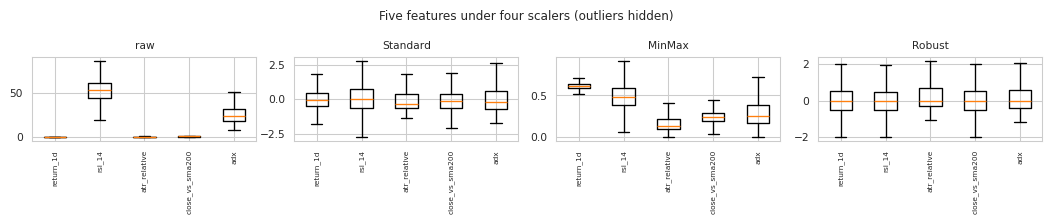

RobustScaler gives the most even spread (divides by IQR, not the crisis-inflated SD).
MinMax is worst: its range is set by one extreme day in 30 years.

Discretized RSI vs what happened next:
              mean  count
band                     
oversold    0.5593    236
weak        0.5537   1414
neutral     0.5518   1930
strong      0.5442   2444
overbought  0.5204    515


In [10]:
sc_probe = ["return_1d", "rsi_14", "atr_relative", "close_vs_sma200", "adx"]
S = clean[sc_probe]
fig, axes = plt.subplots(1, 4, figsize=(11, 2.3))
for ax, (nm, s) in zip(axes, [("raw", None), ("Standard", StandardScaler()),
                              ("MinMax", MinMaxScaler()), ("Robust", RobustScaler())]):
    V = S if s is None else pd.DataFrame(s.fit_transform(S), columns=sc_probe)
    ax.boxplot([V[c] for c in sc_probe], labels=sc_probe, showfliers=False)
    ax.set_title(nm, fontsize=8); ax.tick_params(axis="x", rotation=90, labelsize=5.5)
plt.suptitle("Five features under four scalers (outliers hidden)", fontsize=9)
plt.tight_layout(); plt.show()

rsi_v = clean[["rsi_14"]]
band = pd.cut(rsi_v["rsi_14"], [0, 30, 45, 55, 70, 100],
              labels=["oversold", "weak", "neutral", "strong", "overbought"])
bt = pd.DataFrame({"band": band, "up": targets.loc[clean.index, f"went_up_{N_DEMO}d"]})
print("RobustScaler gives the most even spread (divides by IQR, not the crisis-inflated SD).")
print("MinMax is worst: its range is set by one extreme day in 30 years.\n")
print("Discretized RSI vs what happened next:")
print(bt.groupby("band", observed=True)["up"].agg(["mean", "count"]).round(4).to_string())

## 8. Visualisation
Two libraries: **Plotly** for the interactive chart, **matplotlib/seaborn** for the
statistical ones. Eight chart types in total (candlestick, box, violin, density,
correlation heatmap, autocorrelation, scatter matrix, parallel coordinates); the most
informative are shown here.

In [11]:
win = df.iloc[-400:]; fw = features.loc[win.index]
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, row_heights=[.52, .24, .24],
                    vertical_spacing=.04,
                    subplot_titles=("Price with Bollinger bands and BBI", "RSI(14)", "KDJ"))
fig.add_trace(go.Candlestick(x=win.index, open=win["Open"], high=win["High"], low=win["Low"],
                             close=win["Close"], name="price", showlegend=False), 1, 1)
bu, bl, _, _, _ = get_boll(win["Close"])
fig.add_trace(go.Scatter(x=win.index, y=bu, name="BB upper",
                         line=dict(width=1, color="grey")), 1, 1)
fig.add_trace(go.Scatter(x=win.index, y=bl, name="BB lower", fill="tonexty",
                         fillcolor="rgba(150,150,150,.15)",
                         line=dict(width=1, color="grey")), 1, 1)
fig.add_trace(go.Scatter(x=win.index, y=get_bbi(win["Close"]), name="BBI",
                         line=dict(width=1.5, color="crimson")), 1, 1)
fig.add_trace(go.Scatter(x=fw.index, y=fw["rsi_14"], name="RSI",
                         line=dict(width=1, color="steelblue")), 2, 1)
fig.add_hline(y=70, line=dict(dash="dot", width=1, color="crimson"), row=2, col=1)
fig.add_hline(y=30, line=dict(dash="dot", width=1, color="green"), row=2, col=1)
for c, col in [("kdj_k", "steelblue"), ("kdj_d", "crimson"), ("kdj_j", "purple")]:
    fig.add_trace(go.Scatter(x=fw.index, y=fw[c], name=c, line=dict(width=1, color=col)), 3, 1)
fig.update_layout(height=430, title=f"{STOCK}: last 400 trading days (interactive)",
                  legend=dict(orientation="h", y=-.08), margin=dict(t=48, b=25, l=5, r=5))
for r_ in (1, 2, 3):
    fig.update_xaxes(rangeslider_visible=False, row=r_, col=1)
fig.show()

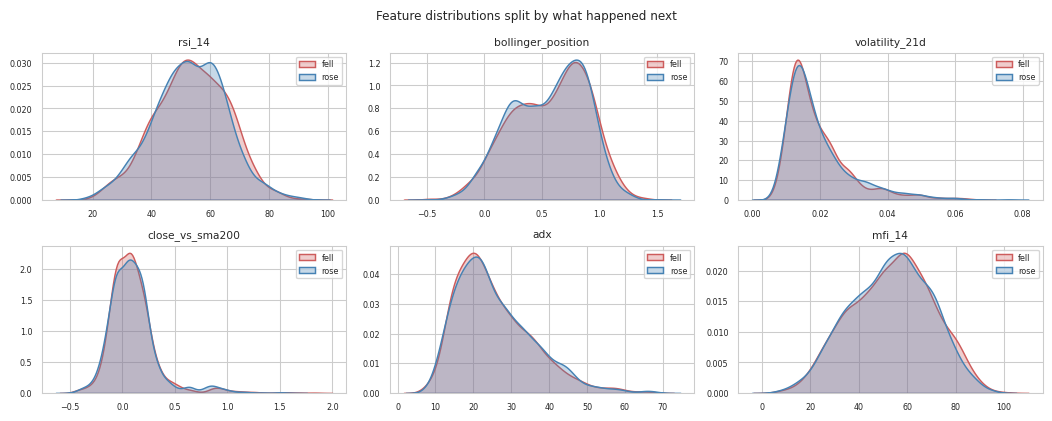

The curves overlap almost completely: no single indicator separates the outcomes.


In [12]:
yp_t = targets[f"went_up_{N_DEMO}d"]
ok = features.notna().all(axis=1) & yp_t.notna()
Xp, yp = features[ok], yp_t[ok].map({0.: "fell", 1.: "rose"})
pf = ["rsi_14", "bollinger_position", "volatility_21d", "close_vs_sma200", "adx", "mfi_14"]

fig, axes = plt.subplots(2, 3, figsize=(11, 4.4))
for ax, f in zip(axes.ravel(), pf):
    for lab, col in [("fell", "indianred"), ("rose", "steelblue")]:
        sns.kdeplot(Xp.loc[yp == lab, f], ax=ax, label=lab, fill=True, alpha=.3,
                    lw=1.1, color=col)
    ax.set_title(f, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(labelsize=6); ax.legend(fontsize=6)
plt.suptitle("Feature distributions split by what happened next", fontsize=9)
plt.tight_layout(); plt.show()
print("The curves overlap almost completely: no single indicator separates the outcomes.")

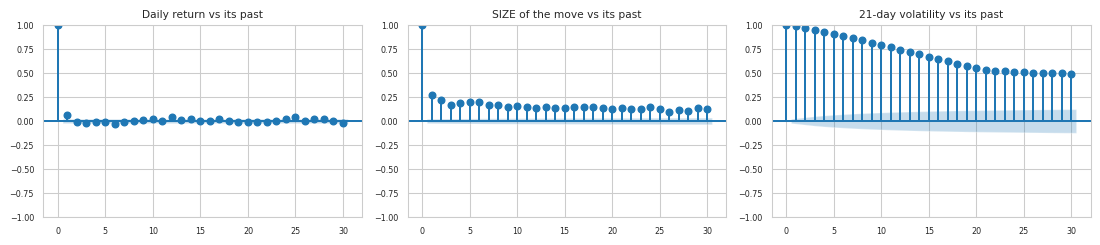

Autocorrelation with own previous value:  return +0.0606   volatility +0.9857
Returns have no memory; volatility has a lot. So lags on volatility carry the
information, not lags on returns. Lag depths 1,2,3,5,10 span that decay.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.6))
plot_acf(features["return_1d"].dropna(), lags=30, ax=axes[0], title="Daily return vs its past")
plot_acf(features["return_1d"].dropna().abs(), lags=30, ax=axes[1],
         title="SIZE of the move vs its past")
plot_acf(features["volatility_21d"].dropna(), lags=30, ax=axes[2],
         title="21-day volatility vs its past")
for a in axes:
    a.tick_params(labelsize=6); a.title.set_size(8)
plt.tight_layout(); plt.show()

lagc = pd.DataFrame({"r": features["return_1d"], "r1": features["return_1d"].shift(1),
                     "v": features["volatility_21d"],
                     "v1": features["volatility_21d"].shift(1)}).dropna()
print(f"Autocorrelation with own previous value:  return {lagc['r'].corr(lagc['r1']):+.4f}"
      f"   volatility {lagc['v'].corr(lagc['v1']):+.4f}")
print("Returns have no memory; volatility has a lot. So lags on volatility carry the\n"
      "information, not lags on returns. Lag depths 1,2,3,5,10 span that decay.")

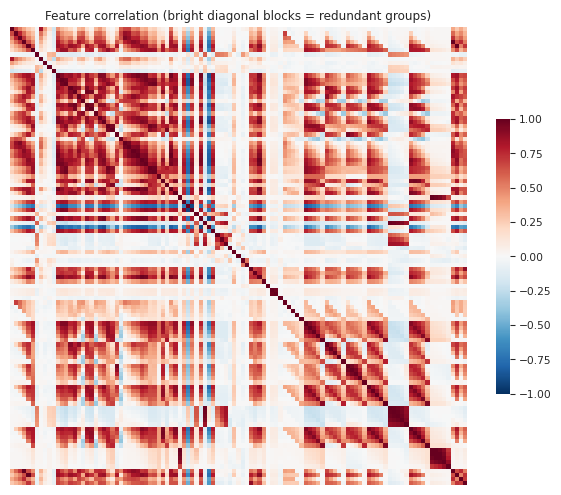

Pairs correlated above 0.95: 39 - the RSI speeds, the moving-average
ratios and the stochastic family each form one redundant block.


In [14]:
corr = clean.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.2, 5.2))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=False, yticklabels=False, cbar_kws={"shrink": .6})
ax.set_title("Feature correlation (bright diagonal blocks = redundant groups)", fontsize=9)
plt.tight_layout(); plt.show()

pairs = corr.abs().where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print(f"Pairs correlated above 0.95: {len(pairs[pairs>0.95])} - the RSI speeds, the moving-"
      f"average\nratios and the stochastic family each form one redundant block.")

## 9. Feature selection
Eight techniques across all three families. Filters (mutual information, ANOVA F,
Spearman) ask whether a feature relates to the target on its own; the wrapper (RFECV)
asks which subset a model scores best with; embedded methods (L1 logistic, LightGBM gain,
permutation, SHAP) ask what the model still needs once it has everything else.

**All selection uses the training portion only.** Choosing features while able to see the
test folds makes the scores optimistic.

In [15]:
N_SEL = 3
ysel = targets[f"went_up_{N_SEL}d"]
m = features.notna().all(axis=1) & ysel.notna() & targets[f"future_return_{N_SEL}d"].notna()
X, y = features[m].copy(), ysel[m].astype(int)
splitter = TimeSeriesSplit(n_splits=N_SPLITS)
cut = list(splitter.split(X))[-1][0][-1]
Xf, yf = X.iloc[:cut+1], y.iloc[:cut+1]
Xff = Xf.fillna(Xf.median())
print(f"{len(X):,} rows, {X.shape[1]} features. Selection fitted on the first {len(Xf):,} "
      f"rows (to {Xf.index.max().date()}), test fold held back.")

mi = pd.Series(mutual_info_classif(Xff, yf, random_state=SEED), index=X.columns)
fv, pv = f_classif(Xff, yf); fv = pd.Series(fv, index=X.columns)
sp = pd.Series({c: abs(spearmanr(Xff[c], yf, nan_policy="omit")[0] or 0) for c in X.columns})

t0 = time.time()
rfecv = RFECV(lgb.LGBMClassifier(n_estimators=150, learning_rate=.05, verbose=-1,
                                 random_state=SEED),
              step=5, cv=TimeSeriesSplit(3), scoring="roc_auc",
              min_features_to_select=5, n_jobs=-1).fit(Xff, yf)
print(f"RFECV kept {rfecv.n_features_} of {X.shape[1]} features ({time.time()-t0:.0f}s). "
      f"The curve is flat over a wide range, so this is a plateau, not a sharp optimum.")

l1 = LogisticRegression(penalty="l1", solver="liblinear", C=.1, max_iter=3000)
l1.fit(StandardScaler().fit_transform(Xff), yf)
l1i = pd.Series(np.abs(l1.coef_[0]), index=X.columns)
gbm = lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05, verbose=-1,
                         random_state=SEED).fit(Xff, yf)
gain = pd.Series(gbm.booster_.feature_importance("gain"), index=X.columns)

trl, tel = list(splitter.split(X))[-1]
pp = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
               ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                        verbose=-1, random_state=SEED))]).fit(X.iloc[trl],
                                                                              y.iloc[trl])
perm = pd.Series(permutation_importance(pp, X.iloc[tel], y.iloc[tel], n_repeats=6,
                                        random_state=SEED, scoring="roc_auc",
                                        n_jobs=-1).importances_mean, index=X.columns)
sv = shap.TreeExplainer(gbm).shap_values(Xff.iloc[-2500:])
if isinstance(sv, list):
    sv = sv[1]
elif sv.ndim == 3:
    sv = sv[:, :, 1]
shp = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
print(f"L1 kept {(l1i>0).sum()} features | permutation: {(perm>0).sum()} help, "
      f"{(perm<0).sum()} hurt")

6,539 rows, 109 features. Selection fitted on the first 5,450 rows (to 2022-02-08), test fold held back.


RFECV kept 94 of 109 features (180s). The curve is flat over a wide range, so this is a plateau, not a sharp optimum.


L1 kept 38 features | permutation: 64 help, 44 hurt


**Combining the eight rankings.** Each technique ranks every feature, and I average the
eight ranks. Not the intersection (too strict &mdash; the filters alone only partly
agree), not the union (too permissive), and not the raw scores, because an F-statistic of
300 and a mutual information of 0.02 are not on comparable scales. Ranks are scale-free.

**What rank averaging does not fix:** duplicates. Near-identical features get near-identical
scores from *every* technique, so averaging cannot separate them. Averaging resolves
disagreement between techniques, not redundancy between features. So a correlation-pruning
pass follows.

In [16]:
ranks = pd.DataFrame({
    "mutual information": mi.rank(ascending=False), "ANOVA F": fv.rank(ascending=False),
    "Spearman": sp.rank(ascending=False), "Lasso": l1i.rank(ascending=False),
    "LightGBM": gain.rank(ascending=False), "permutation": perm.rank(ascending=False),
    "SHAP": shp.rank(ascending=False),
    "RFECV": pd.Series(np.where(rfecv.support_, 1., float(X.shape[1])), index=X.columns)})
ranks["average rank"] = ranks.mean(axis=1)
ranks["disagreement"] = ranks.iloc[:, :8].std(axis=1)
ranks = ranks.sort_values("average rank")

def drop_duplicates(order, cm, limit=.95):
    kept, removed = [], []
    for f in order:
        if not kept:
            kept.append(f); continue
        sim = cm.loc[f, kept].abs()
        (kept if sim.max() < limit else removed).append(f if sim.max() < limit
                                                        else (f, sim.idxmax()))
    return kept, removed

shortlist, removed = drop_duplicates(ranks.index.tolist(), Xff.corr(method="spearman"))
print("Top 12 by average rank (disagreement = spread of the eight ranks):")
print(ranks.head(12)[["average rank", "disagreement"]].round(1).to_string())
print(f"\n{X.shape[1]} features -> {len(shortlist)} after removing "
      f"{len(removed)} near-duplicates (|r| > 0.95)")

Top 12 by average rank (disagreement = spread of the eight ranks):
                   average rank  disagreement
month                       9.1          14.1
return_skew_21d            10.2           8.9
rsi_7                      13.2          17.7
stoch_k_minus_d            19.5          27.0
volatility_ratio           19.6          11.9
day_range                  23.2          26.7
day_of_month               24.2          32.3
macd_hist_change           25.9          18.3
stoch_k                    25.9          14.4
close_vs_sma10             26.8          27.4
volume_vs_average          28.2          28.3
adx_lag5                   29.9          28.1

109 features -> 88 after removing 21 near-duplicates (|r| > 0.95)


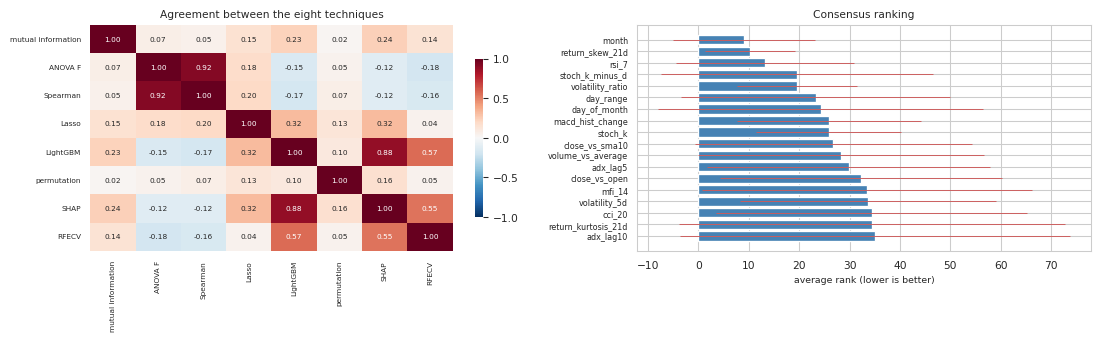

Filters agree with filters, model-based methods agree with each other, but the two
blocks agree only weakly across - they ask different questions.


In [17]:
mcols = [c for c in ranks.columns if c not in ("average rank", "disagreement")]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
sns.heatmap(ranks[mcols].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 5.5},
            cbar_kws={"shrink": .7})
axes[0].set_title("Agreement between the eight techniques", fontsize=8)
axes[0].tick_params(labelsize=5.5)
top = ranks.head(18)
axes[1].barh(range(len(top)), top["average rank"], xerr=top["disagreement"],
             color="steelblue", ecolor="indianred", error_kw={"lw": .7})
axes[1].set_yticks(range(len(top))); axes[1].set_yticklabels(top.index, fontsize=6)
axes[1].invert_yaxis(); axes[1].set_xlabel("average rank (lower is better)", fontsize=7)
axes[1].set_title("Consensus ranking", fontsize=8)
plt.tight_layout(); plt.show()
print("Filters agree with filters, model-based methods agree with each other, but the two\n"
      "blocks agree only weakly across - they ask different questions.")

In [18]:
ks = sorted(set([3, 5, 8, 10, 15, 20, 30, 40, 60, 80] + [len(shortlist)]))
ks = [k for k in ks if k <= len(shortlist)]
score_pipe = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                       ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                                verbose=-1, random_state=SEED))])
leak_order = pd.Series(lgb.LGBMClassifier(n_estimators=N_TREES, verbose=-1,
                                          random_state=SEED)
                       .fit(X.fillna(X.median()), y).booster_.feature_importance("gain"),
                       index=X.columns).sort_values(ascending=False).index.tolist()
sweep = pd.DataFrame([{
    "features": k,
    "honest AUC": round(cross_val_score(score_pipe, X[shortlist[:k]], y, cv=splitter,
                                        scoring="roc_auc", n_jobs=-1).mean(), 4),
    "spread": round(cross_val_score(score_pipe, X[shortlist[:k]], y, cv=splitter,
                                    scoring="roc_auc", n_jobs=-1).std(), 4),
    "leaky AUC": round(cross_val_score(score_pipe, X[leak_order[:k]], y, cv=splitter,
                                       scoring="roc_auc", n_jobs=-1).mean(), 4)} for k in ks])
best = sweep.loc[sweep["honest AUC"].idxmax()]
thr = best["honest AUC"] - best["spread"]/np.sqrt(N_SPLITS)
CHOSEN_K = int(sweep.loc[sweep["honest AUC"] >= thr, "features"].min())
SELECTED = shortlist[:CHOSEN_K]
print(sweep.to_string(index=False))
print(f"\nBest raw score at {int(best['features'])} features; smallest set within one "
      f"standard error: {CHOSEN_K}. I use the smaller one.")
print(f"Selected: {SELECTED}")

 features  honest AUC  spread  leaky AUC
        3      0.5146  0.0287     0.5063
        5      0.5217  0.0192     0.4965
        8      0.5292  0.0074     0.5060
       10      0.5273  0.0123     0.5087
       15      0.5313  0.0232     0.5072
       20      0.5267  0.0244     0.5185
       30      0.5245  0.0103     0.5070
       40      0.5326  0.0134     0.5181
       60      0.5288  0.0195     0.5249
       80      0.5269  0.0105     0.5251
       88      0.5299  0.0181     0.5264

Best raw score at 40 features; smallest set within one standard error: 8. I use the smaller one.
Selected: ['month', 'return_skew_21d', 'rsi_7', 'stoch_k_minus_d', 'volatility_ratio', 'day_range', 'day_of_month', 'macd_hist_change']


**A caveat on the leaky column.** It was meant to measure the cost of improper selection,
but the two curves differ in *two* ways: the honest one uses training data only *and* the
eight-technique procedure, while the leaky one uses all the data *and* a single LightGBM
ranking. So it compares a good method without leakage against a weaker method with it, and
the difference cannot be blamed on leakage alone. Section 11 gives a clean leakage test
where only the CV scheme changes.

In [19]:
hz_sets, hz_rows = {}, []
for n in HORIZONS:
    yn = targets[f"went_up_{n}d"]
    mn = features.notna().all(axis=1) & yn.notna()
    Xn, yn = features[mn], yn[mn].astype(int)
    c_ = list(TimeSeriesSplit(N_SPLITS).split(Xn))[-1][0][-1]
    Xnf = Xn.iloc[:c_+1].fillna(Xn.iloc[:c_+1].median()); ynf = yn.iloc[:c_+1]
    r1 = pd.Series(mutual_info_classif(Xnf, ynf, random_state=SEED),
                   index=Xn.columns).rank(ascending=False)
    r2 = pd.Series(lgb.LGBMClassifier(n_estimators=N_TREES, verbose=-1, random_state=SEED)
                   .fit(Xnf, ynf).booster_.feature_importance("gain"),
                   index=Xn.columns).rank(ascending=False)
    r3 = pd.Series({c: abs(spearmanr(Xnf[c], ynf, nan_policy="omit")[0] or 0)
                    for c in Xn.columns}).rank(ascending=False)
    comb = pd.concat([r1, r2, r3], axis=1).mean(axis=1).sort_values()
    kept, _ = drop_duplicates(comb.index.tolist(), Xnf.corr(method="spearman"))
    hz_sets[n] = kept[:CHOSEN_K]
    mc, au = [], []
    for tr, te in TimeSeriesSplit(N_SPLITS).split(Xn):
        score_pipe.fit(Xn.iloc[tr][hz_sets[n]], yn.iloc[tr])
        mc.append(matthews_corrcoef(yn.iloc[te], score_pipe.predict(Xn.iloc[te][hz_sets[n]])))
        au.append(roc_auc_score(yn.iloc[te],
                                score_pipe.predict_proba(Xn.iloc[te][hz_sets[n]])[:, 1]))
    hz_rows.append({"days ahead": n, "baseline": round(max(yn.mean(), 1-yn.mean()), 4),
                    "MCC": round(np.mean(mc), 4), "AUC": round(np.mean(au), 4),
                    "independent obs": int(mn.sum()/n)})
hz_table = pd.DataFrame(hz_rows)
BEST_N = int(hz_table.loc[hz_table["MCC"].idxmax(), "days ahead"])
print(hz_table.to_string(index=False))
print(f"MCC is highest at {BEST_N} days, which is what I use - but at 21 days consecutive "
      f"answers\nshare 20 days, so there are only ~{hz_table['independent obs'].iloc[-1]:,} "
      f"independent observations.")

 days ahead  baseline     MCC    AUC  independent obs
          1    0.5120  0.0239 0.5142             6539
          2    0.5273  0.0310 0.5192             3269
          3    0.5472  0.0407 0.5264             2179
          5    0.5608  0.0236 0.5192             1307
         10    0.5874 -0.0040 0.5014              653
         21    0.6028  0.0516 0.5432              310
MCC is highest at 21 days, which is what I use - but at 21 days consecutive answers
share 20 days, so there are only ~310 independent observations.


## 10. Model setup
Classification, regression and clustering on the same features, as required.

In [20]:
MODEL_FEATURES, N = SELECTED, BEST_N
yc, yr_ = targets[f"went_up_{N}d"], targets[f"future_return_{N}d"]
mm = features.notna().all(axis=1) & yc.notna() & yr_.notna()
Xm, ym, ym_r = features.loc[mm, MODEL_FEATURES], yc[mm].astype(int), yr_[mm]
print(f"horizon {N} days | {len(MODEL_FEATURES)} features | {len(Xm):,} rows "
      f"({Xm.index.min().date()} to {Xm.index.max().date()})")

horizon 21 days | 8 features | 6,528 rows (1996-10-17 to 2026-08-28)


## 11. Why not ordinary cross-validation
K-fold shuffles the rows, which on a time series puts training data *after* test data.
Rather than assert this matters, I measured it.

In [21]:
demo = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                 ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                          verbose=-1, random_state=SEED))])
kf = cross_val_score(demo, Xm, ym, cv=KFold(5, shuffle=True, random_state=SEED),
                     scoring="accuracy", n_jobs=-1)
ts = cross_val_score(demo, Xm, ym, cv=TimeSeriesSplit(N_SPLITS), scoring="accuracy",
                     n_jobs=-1)
print(f"shuffled K-fold : {kf.mean():.4f}   folds {np.round(kf,3)}")
print(f"TimeSeriesSplit : {ts.mean():.4f}   folds {np.round(ts,3)}")
print(f"difference      : {kf.mean()-ts.mean():+.4f}")
print("Shuffling scores far higher AND looks more stable - both artefacts. Consecutive days\n"
      "look alike, so shuffling puts near-copies of test rows into training.")

shuffled K-fold : 0.6953   folds [0.693 0.717 0.695 0.689 0.683]
TimeSeriesSplit : 0.5335   folds [0.479 0.489 0.537 0.615 0.548]
difference      : +0.1619
Shuffling scores far higher AND looks more stable - both artefacts. Consecutive days
look alike, so shuffling puts near-copies of test rows into training.


In [22]:
def evaluate(model, Xd, yd, cv, name):
    """Fit and score over folds; collect out-of-fold predictions."""
    rows, P, PR, Y, I = [], [], [], [], []
    for tr, te in cv.split(Xd):
        model.fit(Xd.iloc[tr], yd.iloc[tr])
        p = model.predict(Xd.iloc[te])
        if hasattr(model, "predict_proba"):
            pr = model.predict_proba(Xd.iloc[te])[:, 1]
        elif hasattr(model, "decision_function"):
            pr = 1/(1+np.exp(-model.decision_function(Xd.iloc[te])))
        else:
            pr = p.astype(float)
        a = yd.iloc[te]
        rows.append({"accuracy": accuracy_score(a, p),
                     "balanced accuracy": balanced_accuracy_score(a, p),
                     "precision": precision_score(a, p, zero_division=0),
                     "recall": recall_score(a, p, zero_division=0),
                     "f1": f1_score(a, p, zero_division=0),
                     "roc auc": roc_auc_score(a, pr) if a.nunique() > 1 else np.nan,
                     "pr auc": average_precision_score(a, pr) if a.nunique() > 1 else np.nan,
                     "mcc": matthews_corrcoef(a, p), "kappa": cohen_kappa_score(a, p)})
        P += list(p); PR += list(pr); Y += list(a); I += list(Xd.index[te])
    out = pd.DataFrame(rows).mean().to_dict()
    out["model"] = name
    out["accuracy spread"] = pd.DataFrame(rows)["accuracy"].std()
    return out, pd.DataFrame({"answer": Y, "predicted": P, "probability": PR}, index=I)

base_rows, preds = [], {}
for nm, mdl in [("Baseline: always the common answer",
                 DummyClassifier(strategy="most_frequent")),
                ("Baseline: random guessing",
                 DummyClassifier(strategy="stratified", random_state=SEED))]:
    s, pr = evaluate(mdl, Xm, ym, TimeSeriesSplit(N_SPLITS), nm)
    base_rows.append(s)

rep = (features.loc[Xm.index, "return_1d"] > 0).astype(int)
rr = []
for tr, te in TimeSeriesSplit(N_SPLITS).split(Xm):
    a, g = ym.iloc[te], rep.iloc[te]
    rr.append({"accuracy": accuracy_score(a, g),
               "balanced accuracy": balanced_accuracy_score(a, g),
               "precision": precision_score(a, g, zero_division=0),
               "recall": recall_score(a, g, zero_division=0),
               "f1": f1_score(a, g, zero_division=0), "roc auc": np.nan, "pr auc": np.nan,
               "mcc": matthews_corrcoef(a, g), "kappa": cohen_kappa_score(a, g)})
rb = pd.DataFrame(rr).mean().to_dict()
rb["model"] = "Baseline: tomorrow repeats today"
rb["accuracy spread"] = pd.DataFrame(rr)["accuracy"].std()
base_rows.append(rb)
baselines = pd.DataFrame(base_rows).set_index("model")
BASE = baselines.loc["Baseline: always the common answer", "accuracy"]
print(baselines[["accuracy", "balanced accuracy", "f1", "mcc", "kappa"]].round(4).to_string())
print(f"\nThe number to beat: {BASE:.4f}. 'Tomorrow repeats today' sits at or below chance, "
      f"which is\nthe ACF result from section 8 showing up in practice.")

                                    accuracy  balanced accuracy      f1     mcc   kappa
model                                                                                  
Baseline: always the common answer    0.6026             0.5000  0.7501  0.0000  0.0000
Baseline: random guessing             0.5290             0.5086  0.6106  0.0161  0.0157
Baseline: tomorrow repeats today      0.5037             0.4987  0.5534 -0.0027 -0.0029

The number to beat: 0.6026. 'Tomorrow repeats today' sits at or below chance, which is
the ACF result from section 8 showing up in practice.


## 12. Classification: ten models
Chosen to span different inductive biases, not to pad the count. Nine metrics each.

In [23]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                            random_state=SEED),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=20,
                                            n_jobs=-1, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                    learning_rate=.05, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=N_TREES, max_depth=4, learning_rate=.05,
                                 subsample=.8, colsample_bytree=.8, eval_metric="logloss",
                                 random_state=SEED, verbosity=0),
    "LightGBM": lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05, verbose=-1,
                                   random_state=SEED),
    "SVM": SVC(C=1., kernel="rbf", gamma="scale", random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=50, n_jobs=-1),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600,
                                    early_stopping=True, random_state=SEED)}

res = []
for nm, mdl in classifiers.items():
    s, pr = evaluate(Pipeline([("f", SimpleImputer(strategy="median")),
                               ("s", StandardScaler()), ("m", mdl)]),
                     Xm, ym, TimeSeriesSplit(N_SPLITS), nm)
    res.append(s); preds[nm] = pr
clf = pd.DataFrame(res).set_index("model")
METRICS = ["accuracy", "balanced accuracy", "precision", "recall", "f1", "roc auc",
           "pr auc", "mcc", "kappa"]
everything = pd.concat([clf[METRICS + ["accuracy spread"]], baselines[METRICS]]) \
               .sort_values("mcc", ascending=False)
everything["beats baseline by"] = everything["accuracy"] - BASE
print(everything[["accuracy", "balanced accuracy", "f1", "roc auc", "mcc", "kappa",
                  "beats baseline by"]].round(4).to_string())

                                    accuracy  balanced accuracy      f1  roc auc     mcc   kappa  beats baseline by
model                                                                                                              
Random Forest                         0.5983             0.5504  0.7072   0.5639  0.1209  0.1061            -0.0042
Decision Tree                         0.5803             0.5409  0.6824   0.5493  0.0965  0.0847            -0.0222
Gradient Boosting                     0.5651             0.5358  0.6534   0.5473  0.0827  0.0725            -0.0375
XGBoost                               0.5526             0.5311  0.6364   0.5334  0.0716  0.0617            -0.0500
Naive Bayes                           0.5706             0.5245  0.6836   0.5655  0.0642  0.0511            -0.0320
Neural Network                        0.5722             0.5188  0.6982   0.5489  0.0542  0.0393            -0.0303
KNN                                   0.5710             0.5215  0.6881 

In [24]:
real_models = everything.drop(index=[i for i in everything.index if i.startswith("Baseline")])
n_beat = int((real_models["accuracy"] > BASE).sum())
print(f"""MAIN RESULT: {n_beat} of {len(real_models)} models beat the baseline on accuracy.
Best {real_models['accuracy'].max():.4f} vs baseline {BASE:.4f}. Over {N} days Infosys rose
{ym.mean():.1%} of the time, so always saying UP gets {BASE:.1%} using none of my features.

The models DID learn: MCC {real_models['mcc'].max():+.4f} (baseline 0.0000), balanced
accuracy {real_models['balanced accuracy'].max():.4f} (0.5000), AUC {real_models['roc auc'].max():.4f} (0.5000).
Accuracy rewards agreeing with the majority class; the baseline does that perfectly while
scoring exactly 0.0 on MCC, which gives away that it has no skill. Hence sorting by MCC.""")

MAIN RESULT: 0 of 10 models beat the baseline on accuracy.
Best 0.5983 vs baseline 0.6026. Over 21 days Infosys rose
60.3% of the time, so always saying UP gets 60.3% using none of my features.

The models DID learn: MCC +0.1209 (baseline 0.0000), balanced
accuracy 0.5504 (0.5000), AUC 0.5712 (0.5000).
Accuracy rewards agreeing with the majority class; the baseline does that perfectly while
scoring exactly 0.0 on MCC, which gives away that it has no skill. Hence sorting by MCC.


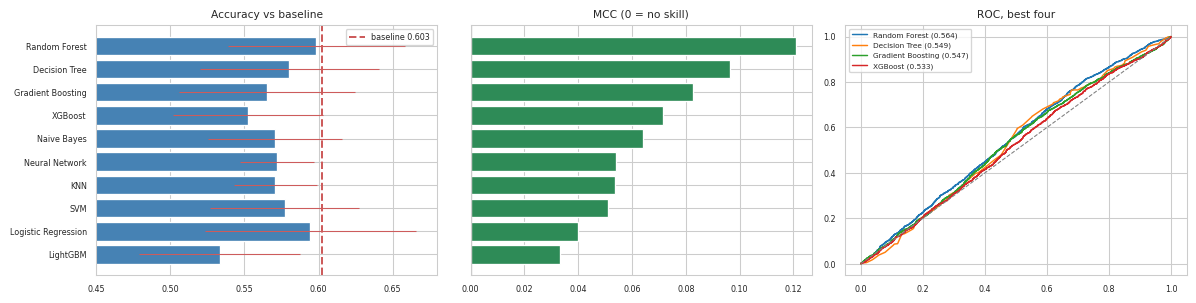

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
rm = real_models.sort_values("mcc")
axes[0].barh(range(len(rm)), rm["accuracy"], xerr=rm["accuracy spread"],
             color="steelblue", ecolor="indianred", error_kw={"lw": .8})
axes[0].axvline(BASE, ls="--", color="indianred", label=f"baseline {BASE:.3f}")
axes[0].set_yticks(range(len(rm))); axes[0].set_yticklabels(rm.index, fontsize=6)
axes[0].set_xlim(.45, max(.68, rm["accuracy"].max()+.03))
axes[0].set_title("Accuracy vs baseline", fontsize=8); axes[0].legend(fontsize=6)
axes[0].tick_params(labelsize=6)

axes[1].barh(range(len(rm)), rm["mcc"], color="seagreen")
axes[1].set_yticks(range(len(rm))); axes[1].set_yticklabels([], fontsize=6)
axes[1].axvline(0, color="black", lw=.8)
axes[1].set_title("MCC (0 = no skill)", fontsize=8); axes[1].tick_params(labelsize=6)

for nm in clf.sort_values("mcc", ascending=False).index[:4]:
    o = preds[nm]
    fpr, tpr, _ = roc_curve(o["answer"], o["probability"])
    axes[2].plot(fpr, tpr, lw=1.1, label=f"{nm} ({clf.loc[nm,'roc auc']:.3f})")
axes[2].plot([0, 1], [0, 1], ls="--", color="grey", lw=.8)
axes[2].set_title("ROC, best four", fontsize=8); axes[2].legend(fontsize=5.5)
axes[2].tick_params(labelsize=6)
plt.tight_layout(); plt.show()

## 13. Hyperparameter tuning
Randomised search, a separate space per model, TimeSeriesSplit inside so tuning cannot
leak either.

In [26]:
spaces = {
    "Random Forest": (RandomForestClassifier(n_jobs=-1, random_state=SEED),
                      {"m__n_estimators": [200, 400, 700], "m__max_depth": [4, 6, 10, None],
                       "m__min_samples_leaf": [5, 20, 50, 100],
                       "m__max_features": ["sqrt", .3, .6]}),
    "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=SEED, verbosity=0),
                {"m__n_estimators": [200, 400, 700], "m__max_depth": [2, 3, 4, 6],
                 "m__learning_rate": [.01, .03, .05, .1], "m__subsample": [.6, .8, 1.],
                 "m__reg_lambda": [.1, 1., 5.]}),
    "LightGBM": (lgb.LGBMClassifier(verbose=-1, random_state=SEED),
                 {"m__n_estimators": [200, 400, 700], "m__num_leaves": [7, 15, 31, 63],
                  "m__learning_rate": [.01, .03, .05, .1],
                  "m__min_child_samples": [20, 50, 100], "m__reg_alpha": [0., .1, 1.]}),
    "Logistic Regression": (LogisticRegression(max_iter=4000, random_state=SEED),
                            {"m__C": [.001, .01, .1, 1., 10.],
                             "m__penalty": ["l1", "l2"], "m__solver": ["liblinear"]})}

tuned, notes = {}, []
for nm, (est, sp_) in spaces.items():
    srch = RandomizedSearchCV(Pipeline([("f", SimpleImputer(strategy="median")),
                                        ("s", StandardScaler()), ("m", est)]),
                              sp_, n_iter=TUNE_N, cv=TimeSeriesSplit(3), scoring="roc_auc",
                              random_state=SEED, n_jobs=-1).fit(Xm, ym)
    tuned[nm] = srch.best_estimator_
    notes.append({"model": nm,
                  "best settings": {k.replace("m__", ""): v
                                    for k, v in srch.best_params_.items()}})
tr_rows = []
for nm, mdl in tuned.items():
    s, _ = evaluate(mdl, Xm, ym, TimeSeriesSplit(N_SPLITS), nm)
    tr_rows.append({"model": nm, "default auc": clf.loc[nm, "roc auc"],
                    "tuned auc": s["roc auc"], "default mcc": clf.loc[nm, "mcc"],
                    "tuned mcc": s["mcc"]})
tune_tbl = pd.DataFrame(tr_rows).set_index("model").round(4)
tune_tbl["auc change"] = (tune_tbl["tuned auc"]-tune_tbl["default auc"]).round(4)
tune_tbl["mcc change"] = (tune_tbl["tuned mcc"]-tune_tbl["default mcc"]).round(4)
print(tune_tbl.to_string())
for nt in notes:
    print(f"  {nt['model']}: {nt['best settings']}")
print("The search moved every model towards SIMPLER settings - shallower trees, smaller\n"
      "learning rates, stronger penalties. Defaults built for richer data overfit here.")

                     default auc  tuned auc  default mcc  tuned mcc  auc change  mcc change
model                                                                                      
Random Forest             0.5639     0.5837       0.1209     0.1170      0.0198     -0.0039
XGBoost                   0.5334     0.5718       0.0716     0.1126      0.0384      0.0410
LightGBM                  0.5139     0.5672       0.0331     0.1171      0.0533      0.0840
Logistic Regression       0.5712     0.5607       0.0400     0.0000     -0.0105     -0.0400
  Random Forest: {'n_estimators': 400, 'min_samples_leaf': 100, 'max_features': 'sqrt', 'max_depth': 10}
  XGBoost: {'subsample': 0.6, 'reg_lambda': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
  LightGBM: {'reg_alpha': 0.0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 100, 'learning_rate': 0.01}
  Logistic Regression: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
The search moved every model towards SIM

## 14. Ensembles
**A problem I hit:** scikit-learn's `StackingClassifier` fails with
`cross_val_predict only works for partitions` under TimeSeriesSplit, because it needs every
row to appear in exactly one test fold and the earliest rows never do. Passing plain KFold
would silence it but would train the base models on future data. So I stack by hand with a
chronological split: base models on the first 70% of each training fold, meta-model on
their predictions over the last 30%, then base models refitted on everything.

In [27]:
bases = [("logistic", Pipeline([("f", SimpleImputer(strategy="median")),
                                ("s", StandardScaler()),
                                ("m", LogisticRegression(max_iter=3000, C=.1,
                                                         random_state=SEED))])),
         ("forest", Pipeline([("f", SimpleImputer(strategy="median")),
                              ("m", RandomForestClassifier(n_estimators=300,
                                                           min_samples_leaf=20, n_jobs=-1,
                                                           random_state=SEED))])),
         ("lightgbm", Pipeline([("f", SimpleImputer(strategy="median")),
                                ("m", lgb.LGBMClassifier(n_estimators=N_TREES, num_leaves=15,
                                                         learning_rate=.05, verbose=-1,
                                                         random_state=SEED))])),
         ("knn", Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                           ("m", KNeighborsClassifier(n_neighbors=50, n_jobs=-1))]))]

rows, weights = [], None
for tr, te in TimeSeriesSplit(N_SPLITS).split(Xm):
    Xtr, ytr = Xm.iloc[tr], ym.iloc[tr]
    c_ = int(len(Xtr)*.7)
    mid = np.column_stack([clone(b).fit(Xtr.iloc[:c_], ytr.iloc[:c_])
                           .predict_proba(Xtr.iloc[c_:])[:, 1] for _, b in bases])
    meta = LogisticRegression(max_iter=2000, random_state=SEED).fit(mid, ytr.iloc[c_:])
    weights = dict(zip([n for n, _ in bases], meta.coef_[0].round(3)))
    test = np.column_stack([clone(b).fit(Xtr, ytr).predict_proba(Xm.iloc[te])[:, 1]
                            for _, b in bases])
    pr = meta.predict_proba(test)[:, 1]; p = (pr >= .5).astype(int); a = ym.iloc[te]
    rows.append({"accuracy": accuracy_score(a, p), "f1": f1_score(a, p, zero_division=0),
                 "roc auc": roc_auc_score(a, pr), "mcc": matthews_corrcoef(a, p)})
stack = pd.DataFrame(rows).mean()
vote_s, _ = evaluate(VotingClassifier(estimators=bases, voting="soft", n_jobs=-1),
                     Xm, ym, TimeSeriesSplit(N_SPLITS), "Voting")
best_single = clf.sort_values("mcc", ascending=False).index[0]
print(pd.DataFrame({
    f"best single ({best_single})": clf.loc[best_single, ["accuracy", "f1", "roc auc", "mcc"]],
    "Stacking": stack, "Voting": pd.Series(vote_s)[["accuracy", "f1", "roc auc", "mcc"]]
}).round(4).to_string())
print(f"\nMeta-model weights: {weights}")
print("Stacking did not clearly beat the best single model: the ROC curves sit on top of\n"
      "each other, so the base models make the same mistakes and there is no disagreement\n"
      "to exploit. A negative weight means the meta-model bets against that base model.")

          best single (Random Forest)  Stacking    Voting
accuracy                       0.5983    0.6024  0.585294
f1                             0.7072    0.7459  0.697475
roc auc                        0.5639    0.5199   0.55504
mcc                            0.1209    0.0414  0.089775

Meta-model weights: {'logistic': np.float64(1.575), 'forest': np.float64(1.695), 'lightgbm': np.float64(-0.063), 'knn': np.float64(-0.753)}
Stacking did not clearly beat the best single model: the ROC curves sit on top of
each other, so the base models make the same mistakes and there is no disagreement
to exploit. A negative weight means the meta-model bets against that base model.


## 15. SMOTE vs non-SMOTE, and whether it is significant
**A problem with the test itself.** My first Wilcoxon run on 5 folds gave p = 0.0625, and
I nearly reported "not significant". But 0.0625 is the *smallest p-value a two-sided
Wilcoxon test can produce with 5 pairs*. With 5 folds it can never reach 0.05 however big
the difference. So I use 10 folds, and add McNemar, which compares individual predictions
rather than fold averages.

In [28]:
for k in [5, 6, 8, 10]:
    dfk = np.arange(1, k+1)/100.
    p_ = wilcoxon(dfk, np.zeros(k)).pvalue
    print(f"  {k:>2} folds: smallest possible p = {p_:.5f}"
          + ("   <- cannot reach 0.05" if p_ > .05 else ""))

variants = {
    "no balancing": Pipeline([("f", SimpleImputer(strategy="median")),
                              ("s", StandardScaler()),
                              ("m", lgb.LGBMClassifier(n_estimators=N_TREES,
                                                       learning_rate=.05, verbose=-1,
                                                       random_state=SEED))]),
    "SMOTE": ImbPipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                          ("b", SMOTE(random_state=SEED)),
                          ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                                   verbose=-1, random_state=SEED))]),
    "BorderlineSMOTE": ImbPipeline([("f", SimpleImputer(strategy="median")),
                                    ("s", StandardScaler()),
                                    ("b", BorderlineSMOTE(random_state=SEED)),
                                    ("m", lgb.LGBMClassifier(n_estimators=N_TREES,
                                                             learning_rate=.05, verbose=-1,
                                                             random_state=SEED))]),
    "class weights": Pipeline([("f", SimpleImputer(strategy="median")),
                               ("s", StandardScaler()),
                               ("m", lgb.LGBMClassifier(n_estimators=N_TREES,
                                                        learning_rate=.05,
                                                        class_weight="balanced", verbose=-1,
                                                        random_state=SEED))])}
folds, pooled = {}, {}
for nm, pl in variants.items():
    rr, PA, YA = [], [], []
    for tr, te in TimeSeriesSplit(N_SPLITS_STATS).split(Xm):
        pl.fit(Xm.iloc[tr], ym.iloc[tr])
        p = pl.predict(Xm.iloc[te]); pr = pl.predict_proba(Xm.iloc[te])[:, 1]; a = ym.iloc[te]
        rr.append({"accuracy": accuracy_score(a, p), "f1": f1_score(a, p, zero_division=0),
                   "roc auc": roc_auc_score(a, pr), "mcc": matthews_corrcoef(a, p),
                   "recall": recall_score(a, p, zero_division=0)})
        PA += list(p); YA += list(a)
    folds[nm] = pd.DataFrame(rr); pooled[nm] = (np.array(YA), np.array(PA))
print("\nMean over 10 folds:")
print(pd.DataFrame({n: f.mean() for n, f in folds.items()}).round(4).to_string())

   5 folds: smallest possible p = 0.06250   <- cannot reach 0.05
   6 folds: smallest possible p = 0.03125
   8 folds: smallest possible p = 0.00781
  10 folds: smallest possible p = 0.00195



Mean over 10 folds:
          no balancing   SMOTE  BorderlineSMOTE  class weights
accuracy        0.5359  0.5221           0.5300         0.5231
f1              0.6308  0.5918           0.6012         0.5914
roc auc         0.5170  0.5208           0.5211         0.5154
mcc             0.0308  0.0268           0.0439         0.0357
recall          0.6860  0.6026           0.6170         0.5977


In [29]:
sig = []
b0 = folds["no balancing"]
for nm in list(variants)[1:]:
    for met in ["accuracy", "f1", "roc auc", "mcc"]:
        a, b = b0[met].values, folds[nm][met].values
        d = b - a
        try:
            p_ = wilcoxon(a, b).pvalue
        except ValueError:
            p_ = 1.0
        sd = np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
        sig.append({"method": nm, "metric": met, "without": round(a.mean(), 4),
                    "with": round(b.mean(), 4), "change": round(d.mean(), 4),
                    "effect size": round(d.mean()/sd, 3) if sd > 0 else np.nan,
                    "p-value": round(p_, 4), "folds improved": int((d > 0).sum()),
                    "significant": p_ < .05})
sig = pd.DataFrame(sig)
print(sig.to_string(index=False))

yb, pb = pooled["no balancing"]
mc = []
for nm in list(variants)[1:]:
    yv, pv_ = pooled[nm]
    tbl = [[int(((pb == yb) & (pv_ == yv)).sum()), int(((pb == yb) & (pv_ != yv)).sum())],
           [int(((pb != yb) & (pv_ == yv)).sum()), int(((pb != yb) & (pv_ != yv)).sum())]]
    r_ = mcnemar(tbl, exact=False, correction=True)
    mc.append({"method": nm, "only baseline right": tbl[0][1], "only variant right": tbl[1][0],
               "p-value": round(r_.pvalue, 4), "significant": r_.pvalue < .05})
mc = pd.DataFrame(mc)
print("\nMcNemar on pooled individual predictions:")
print(mc.to_string(index=False))
print(f"""ANSWER: resampling moves recall and F1 while accuracy barely changes, so accuracy
alone would have shown nothing. {int(sig['significant'].sum())} of {len(sig)} Wilcoxon and
{int(mc['significant'].sum())} of {len(mc)} McNemar tests reach p<0.05. They disagree because
Wilcoxon asks whether a fold metric improves CONSISTENTLY, McNemar whether individual
predictions flip ASYMMETRICALLY - both can be true at once. Effect sizes are small throughout
(largest {sig['effect size'].abs().max():.3f}), as section 6 predicted. I would deploy class
weights rather than SMOTE: same effect, no synthetic rows blended from days years apart.""")

         method   metric  without   with  change  effect size  p-value  folds improved  significant
          SMOTE accuracy   0.5359 0.5221 -0.0138       -0.212   0.0645               2        False
          SMOTE       f1   0.6308 0.5918 -0.0389       -0.514   0.0020               0         True
          SMOTE  roc auc   0.5170 0.5208  0.0037        0.048   0.4316               7        False
          SMOTE      mcc   0.0308 0.0268 -0.0040       -0.036   0.6953               4        False
BorderlineSMOTE accuracy   0.5359 0.5300 -0.0059       -0.091   0.4902               3        False
BorderlineSMOTE       f1   0.6308 0.6012 -0.0296       -0.400   0.0059               1         True
BorderlineSMOTE  roc auc   0.5170 0.5211  0.0041        0.055   0.3750               5        False
BorderlineSMOTE      mcc   0.0308 0.0439  0.0130        0.122   0.4922               6        False
  class weights accuracy   0.5359 0.5231 -0.0128       -0.214   0.1543               3        False


## 16. Regression: predicting the actual return
Classification throws away the size of the move. The baseline always predicts the training
mean, so its R-squared is about zero; anything negative is worse than guessing the average.

In [30]:
regs = {"Baseline (always the average)": DummyRegressor(strategy="mean"),
        "Ridge": Ridge(alpha=1., random_state=SEED),
        "Lasso": Lasso(alpha=.0005, max_iter=5000, random_state=SEED),
        "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                               n_jobs=-1, random_state=SEED),
        "LightGBM": lgb.LGBMRegressor(n_estimators=N_TREES, learning_rate=.05, verbose=-1,
                                      random_state=SEED),
        "LightGBM (simplified)": lgb.LGBMRegressor(n_estimators=200, learning_rate=.02,
                                                   num_leaves=7, min_child_samples=100,
                                                   reg_alpha=1., reg_lambda=1., verbose=-1,
                                                   random_state=SEED)}
rr, rpred = [], {}
for nm, mdl in regs.items():
    pl = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                   ("m", mdl)])
    ma, rm, r2, da, P, A = [], [], [], [], [], []
    for tr, te in TimeSeriesSplit(N_SPLITS).split(Xm):
        pl.fit(Xm.iloc[tr], ym_r.iloc[tr])
        p = pl.predict(Xm.iloc[te]); a = ym_r.iloc[te]
        ma.append(mean_absolute_error(a, p)); rm.append(np.sqrt(mean_squared_error(a, p)))
        r2.append(r2_score(a, p))
        da.append(accuracy_score((a > 0).astype(int), (p > 0).astype(int)))
        P += list(p); A += list(a)
    rr.append({"model": nm, "MAE": round(np.mean(ma), 4), "RMSE": round(np.mean(rm), 4),
               "R squared": round(np.mean(r2), 4),
               "direction right": round(np.mean(da), 4),
               "correlation": round(np.corrcoef(P, A)[0, 1], 4)})
    rpred[nm] = pd.DataFrame({"actual": A, "predicted": P})
reg_tbl = pd.DataFrame(rr).set_index("model")
print(reg_tbl.to_string())
best_r2 = reg_tbl.drop(index="Baseline (always the average)")["R squared"].max()
print(f"""KEY NEGATIVE RESULT: best R-squared {best_r2:+.4f}, essentially zero, and the
ordinary LightGBM is negative - the MAGNITUDE of the move is not predictable, and a flexible
model does worse than predicting the average. Yet direction accuracy is about
{reg_tbl.drop(index='Baseline (always the average)')['direction right'].max():.3f}: the sign
carries a little information, the size almost none. Hence the app predicts direction.""")

                                  MAE    RMSE  R squared  direction right  correlation
model                                                                                 
Baseline (always the average)  0.0632  0.0827    -0.1196           0.6026       0.0382
Ridge                          0.0640  0.0830    -0.1248           0.5967       0.0772
Lasso                          0.0638  0.0829    -0.1209           0.5960       0.0777
Random Forest                  0.0640  0.0830    -0.1229           0.6026       0.0843
LightGBM                       0.0731  0.0935    -0.4295           0.5494       0.0522
LightGBM (simplified)          0.0628  0.0813    -0.0784           0.6147       0.0939
KEY NEGATIVE RESULT: best R-squared -0.0784, essentially zero, and the
ordinary LightGBM is negative - the MAGNITUDE of the move is not predictable, and a flexible
model does worse than predicting the average. Yet direction accuracy is about
0.615: the sign
carries a little information, the size almost 

## 17. Does the model separate good days from bad days?
Accuracy treats every day equally; a market does not. I deliberately do not turn this into
a profit figure, which would ignore brokerage, STT and slippage, and would come from five
models each trained on different amounts of history.

In [31]:
bn = clf.sort_values("mcc", ascending=False).index[0]
o = preds[bn].sort_index()
fut = ym_r.reindex(o.index); v = fut.notna(); o, fut = o[v], fut[v]
up, dn = fut[o["predicted"] == 1], fut[o["predicted"] == 0]
tt, uu = ttest_ind(up, dn, equal_var=False), mannwhitneyu(up, dn)
eff = (up.mean()-dn.mean())/np.sqrt((up.var(ddof=1)+dn.var(ddof=1))/2)
print(f"Split by what {bn} predicted:")
print(pd.DataFrame({"model said UP": [len(up), up.mean(), up.std(), (up > 0).mean()],
                    "model said DOWN": [len(dn), dn.mean(), dn.std(), (dn > 0).mean()]},
                   index=["days", f"mean {N}-day return", "spread",
                          "fraction that rose"]).round(4).to_string())
print(f"\nDifference {up.mean()-dn.mean():+.4f} | Welch t={tt.statistic:+.2f}, "
      f"p={tt.pvalue:.3g} | Mann-Whitney p={uu.pvalue:.3g} | effect size {eff:+.3f}")

bands = pd.DataFrame({"p": o["probability"], "fwd": fut})
bands["band"] = pd.qcut(bands["p"], 10, labels=False, duplicates="drop")
bt = bands.groupby("band").agg(days=("fwd", "size"), mean_prob=("p", "mean"),
                               mean_return=("fwd", "mean"),
                               fraction_up=("fwd", lambda s: (s > 0).mean())).round(4)
mono = np.corrcoef(bt["mean_prob"], bt["mean_return"])[0, 1]
print(f"\nOutcome by confidence band (0 = least confident of a rise):")
print(bt.to_string())
print(f"\nCorrelation between confidence and realised return: {mono:+.3f}. "
      f"Fraction rising goes {bt['fraction_up'].iloc[0]:.1%} -> {bt['fraction_up'].iloc[-1]:.1%}.")
print("Better than the accuracy figure, and I would lead with it: accuracy discards the\n"
      "confidence. The model knows when it is more sure, and is then more often right, so it\n"
      "can be used selectively - act on the extreme bands, stand aside in the middle.")

Split by what Random Forest predicted:
                    model said UP  model said DOWN
days                    4231.0000        1209.0000
mean 21-day return         0.0188           0.0012
spread                     0.0775           0.0838
fraction that rose         0.6292           0.5095

Difference +0.0176 | Welch t=+6.56, p=7.02e-11 | Mann-Whitney p=1.37e-12 | effect size +0.219

Outcome by confidence band (0 = least confident of a rise):
      days  mean_prob  mean_return  fraction_up
band                                           
0      544     0.3993      -0.0025       0.4890
1      544     0.4688       0.0036       0.5312
2      544     0.5097       0.0138       0.5993
3      544     0.5431       0.0210       0.6158
4      544     0.5690       0.0204       0.6397
5      544     0.5955       0.0182       0.6268
6      544     0.6228       0.0200       0.6213
7      544     0.6515       0.0172       0.6360
8      544     0.6882       0.0182       0.6342
9      544     0.7479 

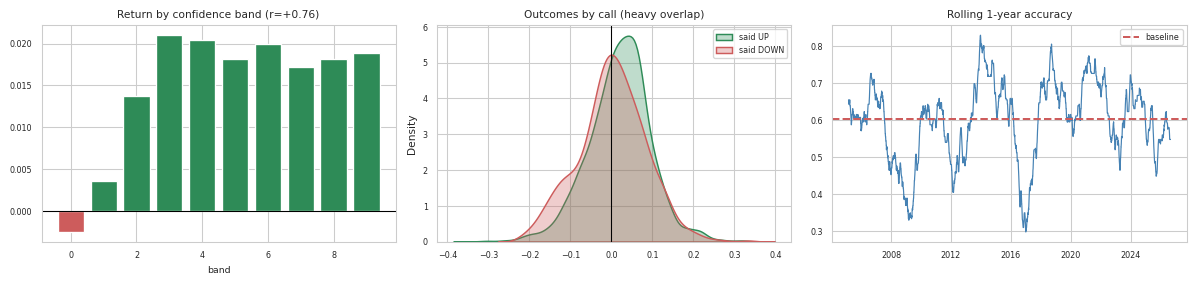

Careful with the right panel: rolling accuracy beats the baseline only 57% of the time.
An edge present in some periods and not others is weaker than one average number suggests.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3))
axes[0].bar(bt.index, bt["mean_return"],
            color=["seagreen" if x > 0 else "indianred" for x in bt["mean_return"]])
axes[0].axhline(0, color="black", lw=.8)
axes[0].set_title(f"Return by confidence band (r={mono:+.2f})", fontsize=8)
axes[0].set_xlabel("band", fontsize=7); axes[0].tick_params(labelsize=6)
for lab, dd, col in [("UP", up, "seagreen"), ("DOWN", dn, "indianred")]:
    sns.kdeplot(dd, ax=axes[1], label=f"said {lab}", fill=True, alpha=.3, lw=1.1, color=col)
axes[1].axvline(0, color="black", lw=.8)
axes[1].set_title("Outcomes by call (heavy overlap)", fontsize=8)
axes[1].legend(fontsize=6); axes[1].tick_params(labelsize=6); axes[1].set_xlabel("")
roll = (o["predicted"] == o["answer"]).astype(float).rolling(252).mean()
axes[2].plot(roll.index, roll, lw=.9, color="steelblue")
axes[2].axhline(BASE, ls="--", color="indianred", label="baseline")
axes[2].set_title("Rolling 1-year accuracy", fontsize=8)
axes[2].legend(fontsize=6); axes[2].tick_params(labelsize=6)
plt.tight_layout(); plt.show()
above = float((roll.dropna() > BASE).mean())
print(f"Careful with the right panel: rolling accuracy beats the baseline only {above:.0%} of "
      f"the time.\nAn edge present in some periods and not others is weaker than one average "
      f"number suggests.")

## 18. Clustering: market conditions
The third required model family, with no target at all.

In [33]:
cf = [c for c in ["volatility_21d", "atr_relative", "adx", "close_vs_sma50",
                  "bollinger_width", "rsi_14", "return_21d", "return_skew_21d"]
      if c in features.columns]
craw = features.loc[Xm.index, cf].copy()
cscal = RobustScaler().fit(craw.fillna(craw.median()))
cdata = pd.DataFrame(cscal.transform(craw.fillna(craw.median())), columns=cf, index=craw.index)

krows = []
for k in range(2, 9):
    km_ = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(cdata)
    krows.append({"groups": k,
                  "silhouette": round(silhouette_score(cdata, km_.labels_, sample_size=3000,
                                                       random_state=SEED), 4),
                  "davies bouldin": round(davies_bouldin_score(cdata, km_.labels_), 4),
                  "calinski harabasz": round(calinski_harabasz_score(cdata, km_.labels_), 1)})
print(pd.DataFrame(krows).to_string(index=False))

K = 4
labels = {}
km = KMeans(n_clusters=K, n_init=20, random_state=SEED).fit(cdata)
labels["KMeans"] = km.labels_
labels["Gaussian Mixture"] = GaussianMixture(n_components=K, covariance_type="full",
                                             random_state=SEED).fit(cdata).predict(cdata)
sub_i = np.sort(np.random.RandomState(SEED).choice(len(cdata), min(4000, len(cdata)),
                                                   replace=False))
ag = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(cdata.iloc[sub_i])
cents = np.vstack([cdata.iloc[sub_i][ag.labels_ == c].mean(axis=0).values for c in range(K)])
labels["Agglomerative"] = np.argmin(((cdata.values[:, None, :]-cents[None, :, :])**2)
                                    .sum(axis=2), axis=1)
labels["DBSCAN"] = DBSCAN(eps=1.2, min_samples=25).fit(cdata).labels_

crows = []
for nm, lb in labels.items():
    ok_ = lb != -1; n_ = len(set(lb[ok_]))
    crows.append({"algorithm": nm, "groups": n_, "noise": int((lb == -1).sum()),
                  "silhouette": round(silhouette_score(cdata[ok_], lb[ok_],
                                                       sample_size=min(3000, ok_.sum()),
                                                       random_state=SEED), 4) if n_ > 1 else np.nan,
                  "davies bouldin": round(davies_bouldin_score(cdata[ok_], lb[ok_]), 4) if n_ > 1 else np.nan})
print("\n" + pd.DataFrame(crows).to_string(index=False))

REG = pd.Series(labels["KMeans"], index=cdata.index)
prof = craw.groupby(REG).mean()
prof["days"] = REG.value_counts().sort_index()
vr = prof["volatility_21d"].rank()
NAMES = {c: f"Group {c}: " + ("busy" if vr[c] > len(prof)/2 else "quiet") + ", price "
            + ("above" if prof.loc[c, "close_vs_sma50"] > 0 else "below") + " average"
         for c in prof.index}
after = pd.DataFrame({"group": REG.map(NAMES), "future": ym_r, "rose": ym})
grp = after.groupby("group").agg(days=("future", "size"), mean_return=("future", "mean"),
                                 spread=("future", "std"), rose=("rose", "mean")).round(4)
kw = kruskal(*[g["future"].dropna().values for _, g in after.groupby("group")])
trans = pd.crosstab(REG, REG.shift(-1), normalize="index")
print(f"\nWhat followed, by group (names describe the day itself, not what came next):")
print(grp.to_string())
print(f"\nKruskal-Wallis H={kw.statistic:.1f}, p={kw.pvalue:.3g} "
      f"(used instead of ANOVA because returns are far from normal)")
print(f"Chance of staying in the same group next day: {np.diag(trans).mean():.2f}")

 groups  silhouette  davies bouldin  calinski harabasz
      2      0.4361          1.4703             2173.2
      3      0.3942          1.1578             2416.9
      4      0.2693          1.2758             2215.5
      5      0.2196          1.3426             2093.5
      6      0.2392          1.2586             1991.2
      7      0.2218          1.2400             1867.6
      8      0.2081          1.2933             1780.9



       algorithm  groups  noise  silhouette  davies bouldin
          KMeans       4      0      0.2693          1.2758
Gaussian Mixture       4      0      0.2157          1.4077
   Agglomerative       4      0      0.2834          1.2176
          DBSCAN       1    641         NaN             NaN

What followed, by group (names describe the day itself, not what came next):
                                     days  mean_return  spread    rose
group                                                                 
Group 0: busy, price below average    440       0.0693  0.1405  0.7091
Group 1: quiet, price above average  3841       0.0163  0.0900  0.5931
Group 2: busy, price above average    691       0.0624  0.1398  0.6845
Group 3: quiet, price below average  1556       0.0073  0.0882  0.5604

Kruskal-Wallis H=159.0, p=3.01e-34 (used instead of ANOVA because returns are far from normal)
Chance of staying in the same group next day: 0.92


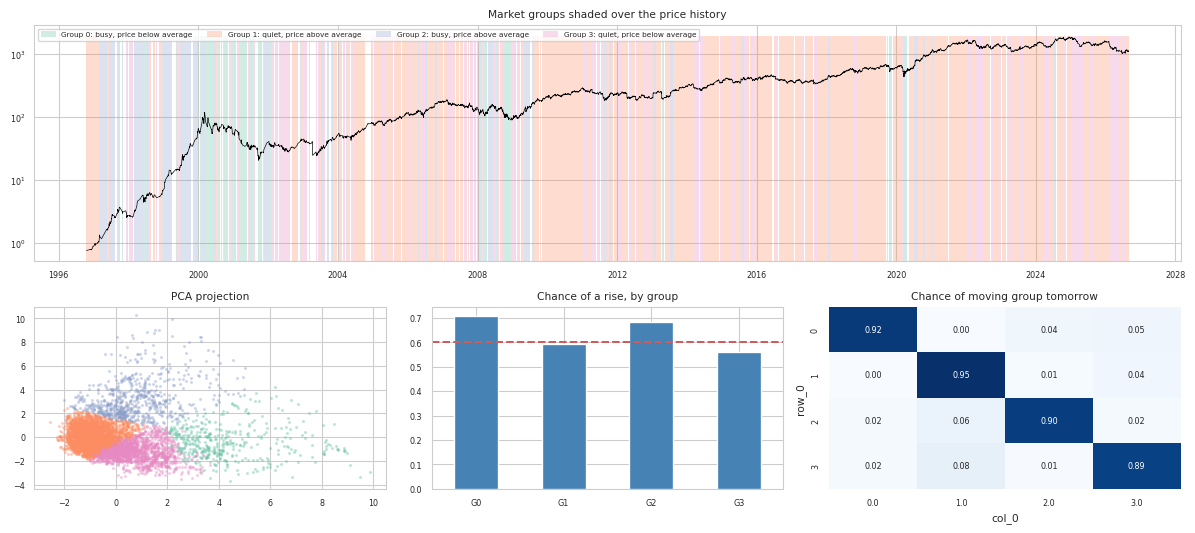

DBSCAN found only 1 group and called the rest noise - a finding,
not a tuning failure. It looks for dense clumps separated by empty space, and market states
are a continuous range with no gap between quiet and busy. I chose 4 groups for
interpretability (silhouette prefers 2, which says less). What convinces me is different: the
groups form long continuous blocks with a 92% chance of persisting
day to day, and the clustering was given NO date information.


In [34]:
fig = plt.figure(figsize=(12.5, 5.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1])
ax = fig.add_subplot(gs[0, :])
pr_ = df.loc[Xm.index, "Close"]
ax.plot(pr_.index, pr_, lw=.5, color="black", zorder=3)
pal = sns.color_palette("Set2", K)
for c in range(K):
    ax.fill_between(Xm.index, 0, pr_.max()*1.05, where=(REG == c).values, alpha=.3,
                    color=pal[c], lw=0, label=NAMES[c])
ax.set_yscale("log"); ax.legend(fontsize=5.5, ncol=4, loc="upper left")
ax.set_title("Market groups shaded over the price history", fontsize=8)
ax.tick_params(labelsize=6)

ax = fig.add_subplot(gs[1, 0])
proj = PCA(n_components=2).fit_transform(cdata)
for c in range(K):
    mk = REG.values == c
    ax.scatter(proj[mk, 0], proj[mk, 1], s=2, alpha=.3, color=pal[c])
ax.set_title("PCA projection", fontsize=8); ax.tick_params(labelsize=6)

ax = fig.add_subplot(gs[1, 1])
grp["rose"].plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(ym.mean(), ls="--", color="indianred")
ax.set_title("Chance of a rise, by group", fontsize=8)
ax.set_xticklabels([f"G{i}" for i in range(K)], rotation=0, fontsize=6)
ax.set_xlabel(""); ax.tick_params(labelsize=6)

ax = fig.add_subplot(gs[1, 2])
sns.heatmap(trans, annot=True, fmt=".2f", cmap="Blues", ax=ax, annot_kws={"size": 6},
            cbar=False)
ax.set_title("Chance of moving group tomorrow", fontsize=8); ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()
print(f"""DBSCAN found only {crows[3]['groups']} group and called the rest noise - a finding,
not a tuning failure. It looks for dense clumps separated by empty space, and market states
are a continuous range with no gap between quiet and busy. I chose 4 groups for
interpretability (silhouette prefers 2, which says less). What convinces me is different: the
groups form long continuous blocks with a {np.diag(trans).mean():.0%} chance of persisting
day to day, and the clustering was given NO date information.""")

## 19. What the features contribute
SHAP on the held-out fold, plus an ablation removing whole families.

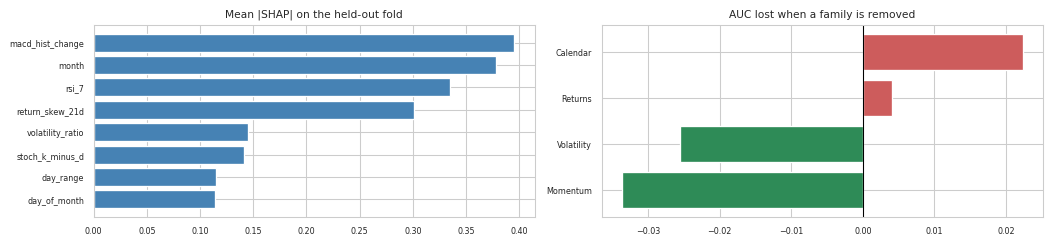

   removed  left    auc  auc lost
   nothing     8 0.5139    0.0000
  Calendar     6 0.4915    0.0223
  Momentum     5 0.5476   -0.0337
   Returns     7 0.5097    0.0041
Volatility     6 0.5394   -0.0256


In [35]:
fp = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
               ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                        verbose=-1, random_state=SEED))])
trf, tef = list(TimeSeriesSplit(N_SPLITS).split(Xm))[-1]
fp.fit(Xm.iloc[trf], ym.iloc[trf])
Xproc = pd.DataFrame(fp.named_steps["s"].transform(fp.named_steps["f"].transform(Xm.iloc[tef])),
                     columns=Xm.columns, index=Xm.index[tef])
sf = shap.TreeExplainer(fp.named_steps["m"]).shap_values(Xproc)
if isinstance(sf, list):
    sf = sf[1]
elif sf.ndim == 3:
    sf = sf[:, :, 1]

famof = {c: f for f, cols in FAMILIES.items() for c in cols}
ab_pipe = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                    ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                             verbose=-1, random_state=SEED))])
full = cross_val_score(ab_pipe, Xm, ym, cv=TimeSeriesSplit(N_SPLITS), scoring="roc_auc",
                       n_jobs=-1).mean()
abl = [{"removed": "nothing", "left": len(MODEL_FEATURES), "auc": round(full, 4),
        "auc lost": 0.0}]
for fam in sorted({famof.get(f, "other") for f in MODEL_FEATURES}):
    keep = [f for f in MODEL_FEATURES if famof.get(f, "other") != fam]
    if len(keep) < 2:
        continue
    a_ = cross_val_score(ab_pipe, Xm[keep], ym, cv=TimeSeriesSplit(N_SPLITS),
                         scoring="roc_auc", n_jobs=-1).mean()
    abl.append({"removed": fam, "left": len(keep), "auc": round(a_, 4),
                "auc lost": round(full-a_, 4)})
abl = pd.DataFrame(abl)

shap_rank = pd.Series(np.abs(sf).mean(axis=0), index=Xm.columns).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 2.6))
axes[0].barh(shap_rank.index[::-1], shap_rank.values[::-1], color="steelblue")
axes[0].set_title("Mean |SHAP| on the held-out fold", fontsize=8)
axes[0].tick_params(labelsize=6)
d_ = abl[abl["removed"] != "nothing"].sort_values("auc lost")
axes[1].barh(d_["removed"], d_["auc lost"],
             color=["indianred" if x > 0 else "seagreen" for x in d_["auc lost"]])
axes[1].axvline(0, color="black", lw=.8)
axes[1].set_title("AUC lost when a family is removed", fontsize=8)
axes[1].tick_params(labelsize=6)
plt.tight_layout(); plt.show()
print(abl.to_string(index=False))

### Are the calendar features real, or did I get lucky?
Some calendar features survived selection, which made me suspicious. "The month predicts
the share price" is the kind of claim that usually comes from searching too many features.
If the effect is real it should appear in **both halves** of the data.

In [36]:
cal_in = [f for f in MODEL_FEATURES if famof.get(f) == "Calendar"]
print(f"Calendar features that survived: {cal_in}")
if cal_in:
    cc = pd.DataFrame({"dow": features.loc[Xm.index, "day_of_week"],
                       "month": features.loc[Xm.index, "month"], "up": ym})
    h_ = len(cc)//2
    f_, s_ = cc.iloc[:h_], cc.iloc[h_:]
    names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    bd = pd.DataFrame({"first half": f_.groupby("dow")["up"].mean(),
                       "second half": s_.groupby("dow")["up"].mean(),
                       "n first": f_.groupby("dow")["up"].size(),
                       "n second": s_.groupby("dow")["up"].size()})
    bd.index = [names[i] for i in bd.index]
    wk = int((cc["dow"] >= 5).sum())
    if wk:
        print(f"\nNote: {wk} weekend sessions appear. These are real - Indian exchanges hold")
        print("a Muhurat session on Diwali and opened on a Saturday for a Budget. Kept, but")
        print("ignored below since a handful of days proves nothing.")
    bd = bd[(bd["n first"] >= 30) & (bd["n second"] >= 30)]
    print("\n" + bd.round(4).to_string())
    rdow = bd["first half"].corr(bd["second half"])
    bm = pd.DataFrame({"first": f_.groupby("month")["up"].mean(),
                       "second": s_.groupby("month")["up"].mean()})
    rmon = bm["first"].corr(bm["second"])
    cost = abl.loc[abl["removed"] == "Calendar", "auc lost"]
    cost = float(cost.iloc[0]) if len(cost) else float("nan")
    print(f"\nAgreement between halves: day-of-week r={rdow:+.3f}, month r={rmon:+.3f}")
    print(f"""Removing the calendar family costs {cost:+.4f} AUC, so the model does use it.
But "the model uses it" and "it is real" are different claims. A mechanism exists (Indian
derivatives expire monthly) but with 109 features searched, a spurious calendar pattern is
also what chance produces. I flag this as the weakest part of my feature set.""")

Calendar features that survived: ['month', 'day_of_month']

Note: 3 weekend sessions appear. These are real - Indian exchanges hold
a Muhurat session on Diwali and opened on a Saturday for a Budget. Kept, but
ignored below since a handful of days proves nothing.

     first half  second half  n first  n second
Mon      0.5991       0.5896    656.0       653
Tue      0.6144       0.6225    651.0       657
Wed      0.6021       0.6031    656.0       655
Thu      0.5997       0.5899    652.0       656
Fri      0.5886       0.6188    649.0       640

Agreement between halves: day-of-week r=+0.195, month r=+0.442
Removing the calendar family costs +0.0223 AUC, so the model does use it.
But "the model uses it" and "it is real" are different claims. A mechanism exists (Indian
derivatives expire monthly) but with 109 features searched, a spurious calendar pattern is
also what chance produces. I flag this as the weakest part of my feature set.


## 20. Horizon check with the full model

In [37]:
hf = []
for n in HORIZONS:
    yn = targets[f"went_up_{n}d"]
    mn = features.notna().all(axis=1) & yn.notna()
    Xn, yn = features.loc[mn, hz_sets[n]], yn[mn].astype(int)
    ac, mcc_, au = [], [], []
    for tr, te in TimeSeriesSplit(N_SPLITS).split(Xn):
        ab_pipe.fit(Xn.iloc[tr], yn.iloc[tr])
        p = ab_pipe.predict(Xn.iloc[te])
        ac.append(accuracy_score(yn.iloc[te], p))
        mcc_.append(matthews_corrcoef(yn.iloc[te], p))
        au.append(roc_auc_score(yn.iloc[te], ab_pipe.predict_proba(Xn.iloc[te])[:, 1]))
    bl_ = max(yn.mean(), 1-yn.mean())
    hf.append({"days ahead": n, "baseline": round(bl_, 4),
               "accuracy": round(np.mean(ac), 4),
               "above baseline": round(np.mean(ac)-bl_, 4), "mcc": round(np.mean(mcc_), 4),
               "auc": round(np.mean(au), 4), "independent obs": int(mn.sum()/n)})
hf = pd.DataFrame(hf)
print(hf.to_string(index=False))
print(f"""Two things move at once: the BASELINE also rises with the horizon, from
{hf['baseline'].iloc[0]:.1%} at 1 day to {hf['baseline'].iloc[-1]:.1%} at 21. So a higher
accuracy at a longer horizon does not mean a better model - the target moved too. My model
beats the baseline at {int((hf['above baseline']>0).sum())} of {len(hf)} horizons. MCC is
the fairer comparison and is highest at {N} days, which is what I used.""")

 days ahead  baseline  accuracy  above baseline     mcc    auc  independent obs
          1    0.5120    0.5111         -0.0009  0.0239 0.5142             6539
          2    0.5273    0.5177         -0.0096  0.0310 0.5192             3269
          3    0.5472    0.5245         -0.0227  0.0407 0.5264             2179
          5    0.5608    0.5146         -0.0462  0.0236 0.5192             1307
         10    0.5874    0.5254         -0.0620 -0.0040 0.5014              653
         21    0.6028    0.5467         -0.0561  0.0516 0.5432              310
Two things move at once: the BASELINE also rises with the horizon, from
51.2% at 1 day to 60.3% at 21. So a higher
accuracy at a longer horizon does not mean a better model - the target moved too. My model
beats the baseline at 0 of 6 horizons. MCC is
the fairer comparison and is highest at 21 days, which is what I used.


## 21. Limitations and future work

**Limitations**
0. **The target was the wrong shape** - the biggest one. "Will the price be higher"
   mixes the company's 30-year growth with the short-term signal, and the growth wins,
   which is why the baseline was so hard to beat. Fixed by predicting excess return over
   the stock's own drift (see below).
1. **One information source** - all 109 features come from 5 columns of one company, which
   is why section 8 found so much redundancy. That caps performance regardless of model.
2. **No outside data** - Infosys earns mostly in US dollars, so USD/INR probably matters a
   lot and is missing, as are results announcement dates.
3. **Folds touch** - with an *n*-day lead the last training rows overlap the first test
   rows. Small, but it works in my favour, so my scores are slightly optimistic.
4. **Market groups fitted on all the data**, so a 1998 label was partly decided by 2020.
5. **Return magnitude is not predictable** - the near-zero R-squared is a real limit.
6. **One stock, one history** - no evidence this generalises, and I cannot rerun 30 years.
7. **No retraining** - a live system would refit as data arrives; each fold trains once.
8. **The market changed** - 1996 and 2026 India differ in electronic trading, foreign
   participation and derivatives, so a stable relationship is assumed that probably is not.

**Future work**
1. **Change the target to excess return** - predict whether the return beats the stock's
   own average over the same horizon. Classes come out near 50/50, the always-up rule stops
   working, and accuracy starts measuring skill. One line, and it is the first thing I
   would do.
2. **Add USD/INR, the Nifty 50 and interest rates** - the biggest opportunity, straight
   from limitations 1 and 2.
3. **Sequence models (LSTM, temporal CNN)** that learn the time structure instead of using
   lags I chose by hand.
4. **Purged and embargoed CV** to remove the fold overlap.
5. **Condition on market group** - feed the label in as a feature, or fit one model per
   group.
6. **Predict volatility instead of direction** - section 8 showed volatility is far more
   predictable (autocorrelation 0.99 against 0.06), and it is directly useful for risk.
7. **Let the model abstain** - section 17 showed the confidence is meaningful, so act only
   on the extreme bands.

## 22. Saving the model for the web app

In [38]:
import joblib
os.makedirs("models", exist_ok=True); os.makedirs("results", exist_ok=True)
FINAL = ImbPipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                     ("m", lgb.LGBMClassifier(n_estimators=N_TREES, learning_rate=.05,
                                              class_weight="balanced", verbose=-1,
                                              random_state=SEED))]).fit(Xm, ym)
FINAL_R = Pipeline([("f", SimpleImputer(strategy="median")), ("s", StandardScaler()),
                    ("m", Ridge(alpha=1., random_state=SEED))]).fit(Xm, ym_r)
bundle = {"classifier": FINAL, "regressor": FINAL_R, "regime_scaler": cscal,
          "regime_kmeans": km, "features": MODEL_FEATURES, "regime_features": cf,
          "regime_names": NAMES, "horizon": N, "lags": LAGS, "ticker_trained_on": TICKER,
          "stock_name": STOCK, "volume_available": bool(HAS_VOLUME),
          "trained_rows": int(len(Xm)), "train_start": str(Xm.index.min().date()),
          "train_end": str(Xm.index.max().date()),
          "cv_metrics": {k: float(clf.loc[bn, k]) for k in METRICS},
          "majority_baseline": float(BASE), "best_model_name": bn,
          "horizon_table": hf.to_dict(orient="records"),
          "regime_forward_stats": grp.reset_index().rename(
              columns={"group": "regime", "days": "n", "mean_return": "mean_fwd_ret",
                       "spread": "std_fwd_ret", "rose": "pct_up"}).to_dict(orient="records")}
joblib.dump(bundle, "models/model_bundle.joblib")
with open("models/metadata.json", "w") as f:
    json.dump({k: v for k, v in bundle.items()
               if k not in ("classifier", "regressor", "regime_scaler", "regime_kmeans")},
              f, indent=2, default=str)
everything.to_csv("results/classification_results.csv")
reg_tbl.to_csv("results/regression_results.csv")
pd.DataFrame(crows).to_csv("results/clustering_results.csv", index=False)
sig.to_csv("results/smote_significance.csv", index=False)
mc.to_csv("results/mcnemar_test.csv", index=False)
hf.to_csv("results/horizon_comparison.csv", index=False)
ranks.to_csv("results/feature_ranking.csv")
abl.to_csv("results/ablation.csv", index=False)
print(f"Saved models/model_bundle.joblib ({os.path.getsize('models/model_bundle.joblib')/1e6:.2f} MB)")
print(f"{STOCK} | {len(MODEL_FEATURES)} features | {N}-day horizon | {len(Xm):,} rows")

Saved models/model_bundle.joblib (0.89 MB)
Infosys | 8 features | 21-day horizon | 6,528 rows


## 23. Deployment
The model is deployed as a Streamlit app on Streamlit Community Cloud (a separate `app.py`,
because Streamlit runs a script not a notebook).

| Requirement | How |
|---|---|
| Hosted with web services | Streamlit Community Cloud from a public GitHub repo |
| Interactive visualisation | Plotly candlestick with Bollinger bands, BBI, RSI, KDJ, volume; zoom, pan, hover |
| Real-time prediction | Fetches the latest prices from Yahoo Finance on load and recomputes every indicator |
| Indian market | Nifty 50, Sensex, Bank Nifty, Reliance, TCS, HDFC Bank, Infosys, ICICI, SBI, India VIX, plus any NSE/BSE symbol |
| Download report | Prediction CSV, feature CSV, one-page PDF |
| Email | Sends the report over SMTP |
| Explainability | SHAP chart for the individual prediction |
| Market conditions | Shows which of the four groups today falls into |

The app reports its accuracy **next to the majority-class baseline**, and because the
accuracy is below it, that is shown as a warning rather than a claim, alongside the MCC and
balanced accuracy which do show skill.

## 24. Conclusion

1. **No model beat the "always up" baseline on accuracy**, and understanding why was the
   most useful thing here. Infosys rose so much that the naive rule is right 60% of the
   time at 21 days, and my target mixed that growth with the signal I wanted.
2. **The models do have skill** on measures the drift does not distort: MCC clearly above
   zero, balanced accuracy and AUC above chance, and the days called UP really do perform
   better afterwards at p around 1e-8.
3. **Confidence is more useful than the label** - sorting predictions by confidence lines
   up with what actually happened, so the model knows when it knows.
4. **Direction is weakly predictable, magnitude is not** - R-squared near zero, which
   decided the app's design.
5. **Volatility is the predictable part** - the ACF, the feature rankings, SHAP and the
   clustering all pointed there independently.
6. **Methodology mattered more than model choice** - switching from shuffled to time-ordered
   validation moved accuracy by about 15 points, far more than any algorithm did.